In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [163]:
import numpy as np
import pandas as pd
import pickle

from dPCA import dPCA

from notebooks.imports import *
from config import dir_config, main_config, ephys_config
from src.utils import pmf_utils, plot_utils, ephys_utils
import os
os.environ["PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT"] = "2.0"
import copy

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

from scipy.spatial.distance import cosine

In [3]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

In [189]:
align_labels = ephys_config["alignment_settings_GP"]

marginalization = {
    'b': 'Bias',
    's': 'Stimulus',
    'c': 'Choice',
    't': 'Time'
}
n_components = 3

In [5]:
plot_params = {
    "color": {0: "blue", 1: "green", 2: "orange", 3: "red"},
    "lw": {0: 2, 1: 1},
    "linestyle": {0: "-", 1: "--"},
    "opacity": {0: 1, 1: 0.3},
}

## Utils

In [16]:
def plot_component(ax, time, data, title=None, plot_mean=False, sig_mask=None, axes_to_loop=None, color=None, alpha=None, linestyle=None, ylim=None):
    # Default axes to loop over if not provided (all axes: b, s, and c)
    if axes_to_loop is None:
        axes_to_loop = marginalization_keys[:-1]  # Loop over all axes: bias (b), stimulus (s), and choice (c)
    axis_indices = {marg: marg_idx for marg_idx,marg in enumerate(marginalization_keys[:-1])}
    axes_not_to_loop = [axis_indices[axis] for axis in axis_indices if axis not in axes_to_loop]


    # Loop over the specified axes (b, s, c)
    for b in np.arange(2) if 'b' in axes_to_loop else [0]:
        for s in [0,1,2,3] if 's' in axes_to_loop else [0]:
            for c in range(2) if 'c' in axes_to_loop else [0]:
                # If we are not plotting the mean, plot the raw data
                if not plot_mean:
                    ax.plot(
                        time,
                        np.squeeze(data[b, s, c, :]),  # Raw data
                        color=plot_params["color"][s] if color is None else color,
                        alpha=plot_params["opacity"][b] if alpha is None else alpha,
                        linestyle=plot_params["linestyle"][c] if linestyle is None else linestyle,
                    )
                else:
                    axes = {'b': b, 's': s, 'c': c}
                    indices = [axes[axis] if axis in axes_to_loop else slice(None) for axis in axis_indices]
                    index_tuple = tuple(indices) + (slice(None),)
                    # Now use the tuple to index the array
                    mean_data = np.mean(np.squeeze(data[index_tuple]), axis=tuple(range(len(axes_not_to_loop))))
                    ax.plot(
                        time,
                        mean_data,  # Plot the mean over the non-looped axes
                        color=plot_params["color"][s] if color is None else color,
                        alpha=plot_params["opacity"][b] if alpha is None else alpha,
                        linestyle=plot_params["linestyle"][c] if linestyle is None else linestyle,
                    )

                lower_ylim = np.nanmin(data)-((np.nanmax(data) - np.nanmin(data))*0.05)-0.05
                upper_ylim = np.nanmax(data) + ((np.nanmax(data) - np.nanmin(data))*0.05)+0.05
                if sig_mask is not None:
                    ax.imshow(sig_mask, extent=[time[0], time[-1], lower_ylim, np.amin(data)-0.05], aspect='auto', cmap='gray_r', vmin=0, vmax=1)
                ax.set_title(title)
                ax.set_ylim(ylim) if ylim else ax.set_ylim(lower_ylim, upper_ylim)
                ax.axvline(0, color="black", linestyle="--", linewidth=1)

In [9]:
def plot_single_pc_projection(dpca_axis, prior, dpca_results, pc_component=0, ylim=None, legend=False):
    print(f"Prior: {prior.split('_')[0]}")
    PC_num = pc_component
    alignment_dict = ephys_config["alignment_settings_GP"]
    alignment_fields = ["target_onset","stimulus_onset", "response_onset"]

    fig, ax = plt.subplots(1, len(alignment_fields), figsize = (5*len(alignment_fields), 5))
    for idx, alignment in enumerate(alignment_fields):
        # Get transformed data
        Z = dpca_results[prior][alignment]["transformed_data"]
        sig_mask = None #significance_masks[prior][alignment] if plot_sig_mask else None

        # Align the duration based on the alignment type
        aligned_duration = np.arange(alignment_dict[alignment]["start_time_ms"], alignment_dict[alignment]["end_time_ms"] + 1)
        time = aligned_duration[-np.arange(Z['t'].shape[-1]) - 1][::-1] if alignment == "response_onset" else aligned_duration[np.arange(Z['t'].shape[-1])]
        # Set step size based on alignment type
        step = 50 if alignment == "response_onset" else 100

        x = time
        if dpca_axis == 'time':
            y, label = Z['t'][PC_num,:], f"time for PC {PC_num+1}"
        elif dpca_axis == 'bias':
            y, label = Z['b'][PC_num, :], f"bias PC {PC_num+1}"
        elif dpca_axis == "stimulus":
            y, label = Z['s'][PC_num, :], f"stimulus PC {PC_num+1}"
        elif dpca_axis == 'choice':
            y, label = Z['c'][PC_num, :], f"choice PC {PC_num+1}"
        elif dpca_axis == 'stimulus-bias':
            y, label = Z['bs'][PC_num, :], f"stimulus-bias interaction PC {PC_num+1}"
        elif dpca_axis == 'choice-bias':
            y, label = Z['bc'][PC_num, :], f"choice-bias interaction PC {PC_num+1}"
        if idx < 2:
            plot_component(ax[idx], x, y, ylim=ylim)
        else:
            plot_component(ax[idx], x, y)
        ax[idx].set_xlabel(alignment.capitalize().replace('_', ' '))

    ax[1].set_yticks([])

    if legend:
        # Add the legend for different lines
        handles = [
            plt.Line2D([0], [0], color="red", label="50% coh"),
            plt.Line2D([0], [0], color="orange", label="20% coh"),
            plt.Line2D([0], [0], color="green", label="6% coh"),
            plt.Line2D([0], [0], color="blue", label="0% coh"),
            plt.Line2D([0], [0], color='k', alpha=1, label="biased state"),
            plt.Line2D([0], [0], color='k', alpha=0.3, label="unbiased state"),
            plt.Line2D([0], [0], color='k', linestyle="-", label="toRF choice"),
            plt.Line2D([0], [0], color='k', linestyle="--", label="awayRF choice"),
        ]
        fig.legend(handles=handles, bbox_to_anchor=(1, 1), loc='upper right')

    fig.suptitle(f"{dpca_axis.capitalize()} Projection")
    plt.show()

In [14]:
def plot_dPCA_projection_sig(plot_mean, plot_sig_mask, prior, ephys_config, dpca_results):
    alignment_dict = ephys_config["alignment_settings_GP"]
    print(f"Prior: {prior.split('_')[0]}")
    for alignment in alignment_dict.keys():
        # Get transformed data
        Z = dpca_results[alignment][prior][alignment]["transformed_data"]
        sig_mask = significance_masks[prior][alignment] if plot_sig_mask else None

        # Align the duration based on the alignment type
        aligned_duration = np.arange(alignment_dict[alignment]["start_time_ms"], alignment_dict[alignment]["end_time_ms"] + 1)
        time = aligned_duration[-np.arange(Z['t'].shape[-1]) - 1][::-1] if alignment == "response_onset" else aligned_duration[np.arange(Z['t'].shape[-1])]
        # Set step size based on alignment type
        step = 50 if alignment == "response_onset" else 100

        fig, axes = plt.subplots(2, 5, figsize=(24, 10))

        # Loop through the principal components (PCs)
        for PC_num in range(1):
            if plot_mean:
                plot_component(axes[PC_num, 0], time, Z['t'][PC_num,:], f"time PC {PC_num+1}")
                plot_component(axes[PC_num, 1], time, Z['b'][PC_num, :], f"bias PC {PC_num+1}", plot_mean=True, sig_mask=sig_mask['b'][PC_num][None,:] if plot_sig_mask else None,
                               axes_to_loop=['b'], color='k', linestyle=plot_params["linestyle"][0])
                plot_component(axes[PC_num, 2], time, Z['s'][PC_num, :], f"stimulus PC {PC_num+1}", plot_mean=True, sig_mask=sig_mask['s'][PC_num][None,:] if plot_sig_mask else None,
                               axes_to_loop=['s'], alpha=plot_params["opacity"][0], linestyle=plot_params["linestyle"][0])
                plot_component(axes[PC_num, 3], time, Z['c'][PC_num, :], f"choice PC {PC_num+1}", plot_mean=True, sig_mask=sig_mask['c'][PC_num][None,:] if plot_sig_mask else None,
                               axes_to_loop=['c'],color='k', alpha=plot_params["opacity"][0])
                plot_component(axes[PC_num, 4], time, Z['bs'][PC_num, :], f"stimulus-bias interaction PC {PC_num+1}", sig_mask=sig_mask['bs'][PC_num][None,:] if plot_sig_mask else None,
                               plot_mean=True, axes_to_loop=['b','s'],linestyle=plot_params["linestyle"][0])

            else:
                plot_component(axes[PC_num, 0], time, Z['t'][PC_num,:], f"time PC {PC_num+1}")
                plot_component(axes[PC_num, 1], time, Z['b'][PC_num,:],f"bias PC {PC_num+1}", sig_mask=sig_mask['b'][PC_num][None,:] if plot_sig_mask else None)
                plot_component(axes[PC_num, 2], time, Z['s'][PC_num,:], f"stimulus PC {PC_num+1}", sig_mask=sig_mask['s'][PC_num][None,:] if plot_sig_mask else None)
                plot_component(axes[PC_num, 3], time, Z['c'][PC_num,:], f"choice PC {PC_num+1}", sig_mask=sig_mask['c'][PC_num][None,:] if plot_sig_mask else None)
                plot_component(axes[PC_num, 4], time, Z['bs'][PC_num,:], f"stimulus-bias interaction PC {PC_num+1}", sig_mask=sig_mask['bs'][PC_num][None,:] if plot_sig_mask else None)

        # Add the legend for different lines
        handles = [
            plt.Line2D([0], [0], color="red", label="50% coh"),
            plt.Line2D([0], [0], color="orange", label="20% coh"),
            plt.Line2D([0], [0], color="green", label="6% coh"),
            plt.Line2D([0], [0], color="blue", label="0% coh"),
            plt.Line2D([0], [0], color='k', alpha=1, label="biased state"),
            plt.Line2D([0], [0], color='k', alpha=0.3, label="unbiased state"),
            plt.Line2D([0], [0], color='k', linestyle="-", label="toRF choice"),
            plt.Line2D([0], [0], color='k', linestyle="--", label="awayRF choice"),
        ]
        fig.legend(handles=handles, bbox_to_anchor=(1, 1), loc='upper right')
        fig.suptitle(f"Aligned to {alignment.capitalize().replace('_', ' ')}")
        plt.show()


In [10]:
def classification(class_means, test):
    Q = class_means.shape[0]
    T = class_means.shape[1]
    performance = np.zeros(T)
    distance = 0.

    # classify every data point in test according to nearest class mean
    for t in range(T):
        if np.any(np.isnan(test[:,t])): # if any test data is nan, skip this time point
            performance[t] = np.nan
        else:
            for p in range(Q):
                argmin = 0
                distance = abs(class_means[argmin,t] - test[p,t])

                # find closest class mean
                for q in range(1,Q):
                    if abs(class_means[q,t] - test[p,t]) < distance:
                        distance = abs(class_means[q,t] - test[p,t])
                        argmin = q

                # add 1 if class is correct
                if argmin == p:
                    performance[t] += 1.

        performance[t] /= Q

    return performance

def denoise_mask(mask, n_consecutive):
    subseq = 0
    N = mask.shape[0]

    for n in range(N):
        if mask[n] == 1:
            subseq += 1
        else:
            if subseq < n_consecutive:
                for k in range(n-subseq,n):
                    mask[k] = 0

    return mask

def flat2d(A):
        ''' Flattens all but the first axis of an ndarray, returns view. '''
        return A.reshape((A.shape[0],-1))

def dpca_transform(dpca, X):
    X = X - np.nanmean(X.reshape((X.shape[0],-1)),1).reshape((X.shape[0],) + (len(X.shape)-1)*(1,))
    total_variance = np.sum((X - np.nanmean(X))**2)
    def marginal_variances(marginal):
        ''' Computes the relative variance explained of each component
            within a marginalization
        '''
        D, Xr = dpca.D[marginal], X.reshape((X.shape[0],-1))
        return [np.sum(np.dot(D[:,k], Xr)**2) / total_variance for k in range(D.shape[1])]

    X_transformed = {}
    dpca.explained_variance_ratio_ = {}
    for key in list(dpca.marginalizations.keys()):
        X_transformed[key] = np.dot(dpca.D[key].T, X.reshape((X.shape[0],-1))).reshape((dpca.D[key].shape[1],) + X.shape[1:])
        dpca.explained_variance_ratio_[key] = marginal_variances(key)
    return dpca, X_transformed

def dpca_train_test_split(dpca,X,trialX,N_samples=None,sample_ax=0):
    protect = dpca.protect
    n_unprotect = len(X.shape) - len(protect) if protect is not None else len(X.shape)
    n_protect   = len(protect) if protect is not None else 0

    if sample_ax != 0:
        raise NotImplemented('The sample axis needs to come first.')

    # test if all protected axes lie at the end
    protected = dpca._check_protected(trialX,protect)

    # reorder matrix to protect certain axis (for speedup)
    if ~protected:
        # turn crossval_protect into index listX
        axes = [dpca.labels.index(ax) + 2 for ax in protect]

        # reorder matrix
        trialX = dpca._roll_back(trialX,axes)
        X = np.squeeze(dpca._roll_back(X[None,...],axes))

    # compute number of samples in each condition
    if N_samples is None:
        N_samples = dpca._get_n_samples(trialX,protect=dpca.protect)

    # get random indices
    idx = (np.random.rand(*N_samples.shape)*N_samples).astype(int)

    # select values
    blindX = np.empty(trialX.shape[1:])

    # iterate over multi_index
    it = np.nditer(np.empty(N_samples.shape), flags=['multi_index'])

    while not it.finished:
        blindX[it.multi_index + (np.s_[:],)*n_protect] = trialX[(idx[it.multi_index],) + it.multi_index + (np.s_[:],)*n_protect]
        it.iternext()

    # compute trainX
    trainX = (X * (N_samples / (N_samples - 1))[(np.s_[:],) * n_unprotect + (None,) * n_protect]
          - np.where(np.isnan(blindX), X, blindX) / (N_samples - 1)[(np.s_[:],) * n_unprotect + (None,) * n_protect])

    # trainX = (X*(N_samples/(N_samples-1))[(np.s_[:],)*n_unprotect + (None,)*n_protect] - blindX/(N_samples-1)[(np.s_[:],)*n_unprotect + (None,)*n_protect])

    # inverse rolled axis in blindX
    if ~protected:
        blindX = dpca._roll_back(blindX[...,None],axes,invert=True)[...,0]
        trainX = dpca._roll_back(trainX[...,None],axes,invert=True)[...,0]

    # remean datasets (both equally)
    trainX -= np.nanmean(flat2d(trainX),1)[(np.s_[:],) + (None,)*(len(X.shape)-1)]
    blindX -= np.nanmean(flat2d(blindX),1)[(np.s_[:],) + (None,)*(len(X.shape)-1)]

    return trainX, blindX

def compute_mean_score(dpca, X, trialX, n_splits, keys, axis=None):
    K = X.shape[-1]

    if type(dpca.n_components) == int:
        scores = {key : np.empty((dpca.n_components, n_splits, K)) for key in keys}
    else:
        scores = {key : np.empty((dpca.n_components[key], n_splits, K)) for key in keys}

    for shuffle in range(n_splits):
        print('.', end=' ')

        # do train-validation split
        trainX, validX = dpca_train_test_split(dpca,X,trialX)
        # fit a dPCA model to training data & transform validation data
        dpca.fit(trainX)
        dpca, trainZ = dpca_transform(dpca, trainX)
        dpca, validZ = dpca_transform(dpca, validX)

        # reshape data to match Cython input
        for key in keys:
            ncomps = dpca.n_components if type(dpca.n_components) == int else dpca.n_components[key]

            # mean over all axis not in key
            axset = dpca.marginalizations[key]
            axset = axset if type(axset) == set else set.union(*axset)
            if axis is None:
                axes = set(range(len(X.shape)-1)) - axset
            else:
                axes = set(range(len(X.shape)-1)) - axset - {len(X.shape)-2}
            for ax in list(axes)[::-1]:
                trainZ[key] = np.nanmean(trainZ[key],axis=ax+1)
                validZ[key] = np.nanmean(validZ[key],axis=ax+1)

            # reshape
            if (len(X.shape)-2 in axset) or (axis):
                trainZ[key] = trainZ[key].reshape((ncomps,-1,K))
                validZ[key] = validZ[key].reshape((ncomps,-1,K))
            else:
                trainZ[key] = trainZ[key].reshape((ncomps,-1,1))
                validZ[key] = validZ[key].reshape((ncomps,-1,1))

        # compute classification score
        for key in keys:
            ncomps = dpca.n_components if type(dpca.n_components) == int else dpca.n_components[key]
            for comp in range(ncomps):
                scores[key][comp, shuffle] = classification(trainZ[key][comp],validZ[key][comp])

    for key in keys:
        scores[key] = np.nanmean(scores[key], axis=1)

    return scores

def dpca_significance_analysis(dpca, X, trialX, n_shuffles=100, n_splits=100, n_consecutive=10, axis=None, full=False):

    if dpca.opt_regularizer_flag:
        print("Regularization not optimized yet; start optimization now.")
        dpca._optimize_regularization(X,trialX)

    keys = list(dpca.marginalizations.keys())
    keys.remove(dpca.labels[-1])

    # shuffling is in-place, so we need to copy the data
    trialX_shuffled = trialX.copy()

    # compute score of original data
    print("Compute score of data: ", end=' ')
    true_score = compute_mean_score(dpca, X, trialX, n_splits, keys, axis=axis)
    print("Finished.")

    # data collection
    scores = {key : [] for key in keys}
    shuffled_transformed_data = [{} for _ in range(n_shuffles)]

    # iterate over shuffles
    for it in range(n_shuffles):
        print("\rCompute score of shuffled data: ", str(it), "/", str(n_shuffles), end=' ')
        trialX_shuffled = dpca.shuffle_labels(trialX_shuffled)
        # mean trial-by-trial data
        X_shuffled = np.nanmean(trialX_shuffled,axis=0)
        # remove any timepoints with nan in X
        no_any_nan_mask = ~np.any(np.isnan(X_shuffled), axis=(0, 1, 2, 3))
        X_shuffled = X_shuffled[...,no_any_nan_mask]
        trialX_shuffled = trialX_shuffled[...,no_any_nan_mask]
        dpca, shuffled_transformed_data[it] = dpca_transform(dpca,X_shuffled)

        score = compute_mean_score(dpca,X_shuffled,trialX_shuffled,n_splits,keys,axis=axis)
        for key in keys:
            scores[key].append(score[key])

    # binary mask, if data score is above maximum shuffled score make true
    masks = {key: np.full(true_score[key].shape, False) for key in keys} # default is False
    for key in keys:
        min_length = min(shuffle_score.shape[1] for shuffle_score in scores[key]) # find minimum length of shuffled scores
        # maxscore = np.amax(np.dstack([shuffle_score[:,:min_length] for shuffle_score in scores[key]]),-1)
        quantile_score = np.nanquantile(np.dstack([shuffle_score[:,:min_length] for shuffle_score in scores[key]]), 0.95, axis=-1)
        masks[key][:,:min_length] = true_score[key][:,:min_length] > quantile_score

    if n_consecutive > 1:
        for key in keys:
            mask = masks[key]
            for k in range(mask.shape[0]):
                masks[key][k,:] = denoise_mask(mask[k].astype(np.int32),n_consecutive)

    if full:
        return masks, true_score, scores, shuffled_transformed_data
    else:
        return masks

def dpca_shuffle(dpca, trialX, n_shuffles = 10):
    shuffled_Z = {}
    for n_shuffle in range(n_shuffles):
        # shuffle labels
        trialX = dpca.shuffle_labels(trialX)
        # mean trial-by-trial data
        X = np.nanmean(trialX,axis=0)
        # remove any timepoints with nan in X
        no_any_nan_mask = ~np.any(np.isnan(X), axis=(0, 1, 2, 3))
        X = X[...,no_any_nan_mask]
        trialX = trialX[...,no_any_nan_mask]
        dpca.fit(X,trialX)
        _, shuffled_Z[n_shuffle] = dpca_transform(dpca, X)
    min_timepoints = np.min([shuffled_Z[n_shuffle]['t'].shape[4] for n_shuffle in range(n_shuffles)])
    mean_shuffled_Z = {key:[] for key in dpca.explained_variance_ratio_}
    for key in dpca.explained_variance_ratio_:
        mean_shuffled_Z[key] = np.mean(np.array([shuffled_Z[n_shuffle][key][...,0:min_timepoints] for n_shuffle in range(n_shuffles)]), axis=0)

    return shuffled_Z, mean_shuffled_Z

## Load data

In [ ]:
session_to_exclude = ["210210_GP_JP","241209_GP_TZ"]

session_metadata = pd.read_csv(Path(processed_dir, 'sessions_metadata.csv'))
session_metadata = session_metadata[~np.isin(session_metadata["session_id"],session_to_exclude)]

neuron_metadata = pd.read_csv(Path(compiled_dir, 'neuron_metadata.csv'))
neuron_metadata = neuron_metadata[~np.isin(neuron_metadata["session_id"],session_to_exclude)]

with open(Path(processed_dir, f'dpca_data_and_projection.pkl'), 'rb') as f:
    dpca_data_and_projection = pickle.load(f)
dpca_projection = dpca_data_and_projection["projection"]

In [11]:
# project back to cropped average data
average_data = dpca_data_and_projection["data"]["average"]
for prior in ["toRF_prior", "awayRF_prior"]:
    for alignment in ephys_config["alignment_settings_GP"]:
        dpca = dpca_projection[alignment][prior]["model"]
        _, dpca_projection[alignment][prior][alignment]["transformed_data"] = dpca_transform(dpca, average_data[prior][alignment])

In [12]:
target_onset_projection = dpca_projection["target_onset"]
stimulus_onset_projection = dpca_projection["stimulus_onset"]
response_onset_projection = dpca_projection["response_onset"]

### plot projection

Prior: toRF


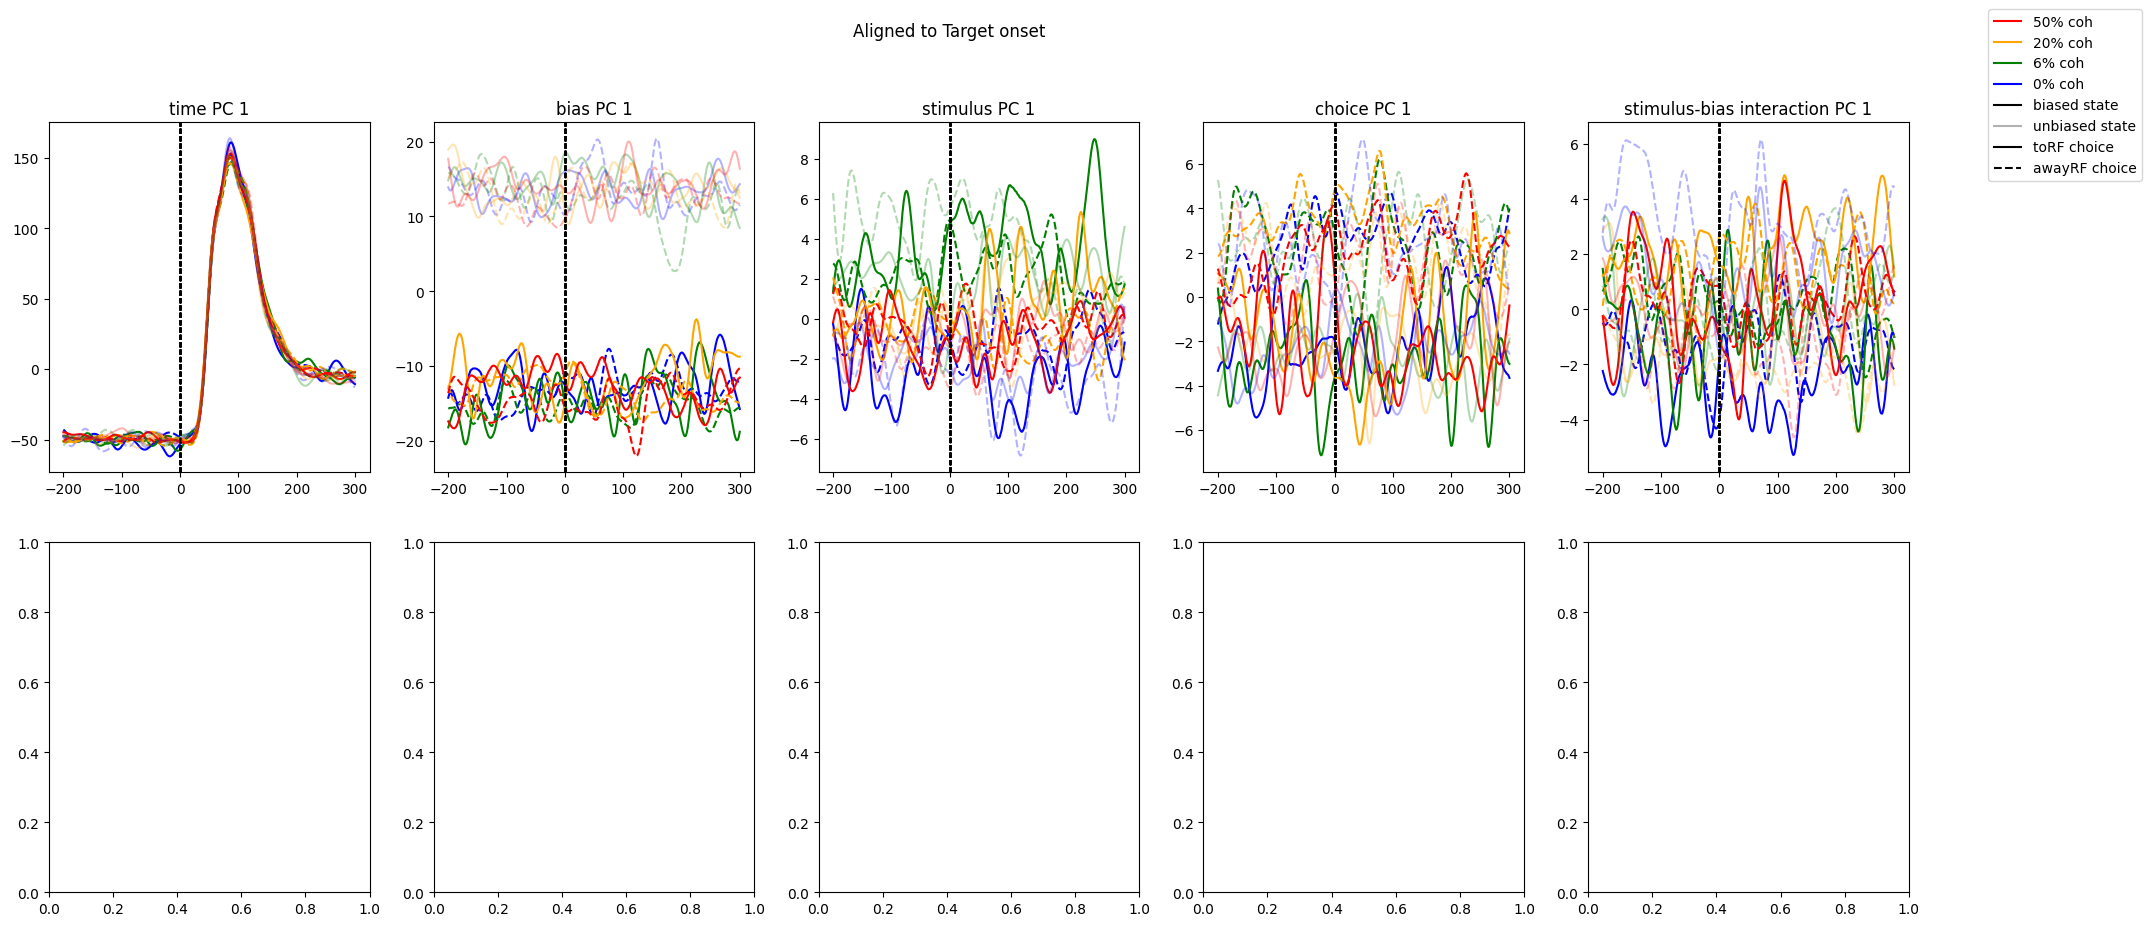

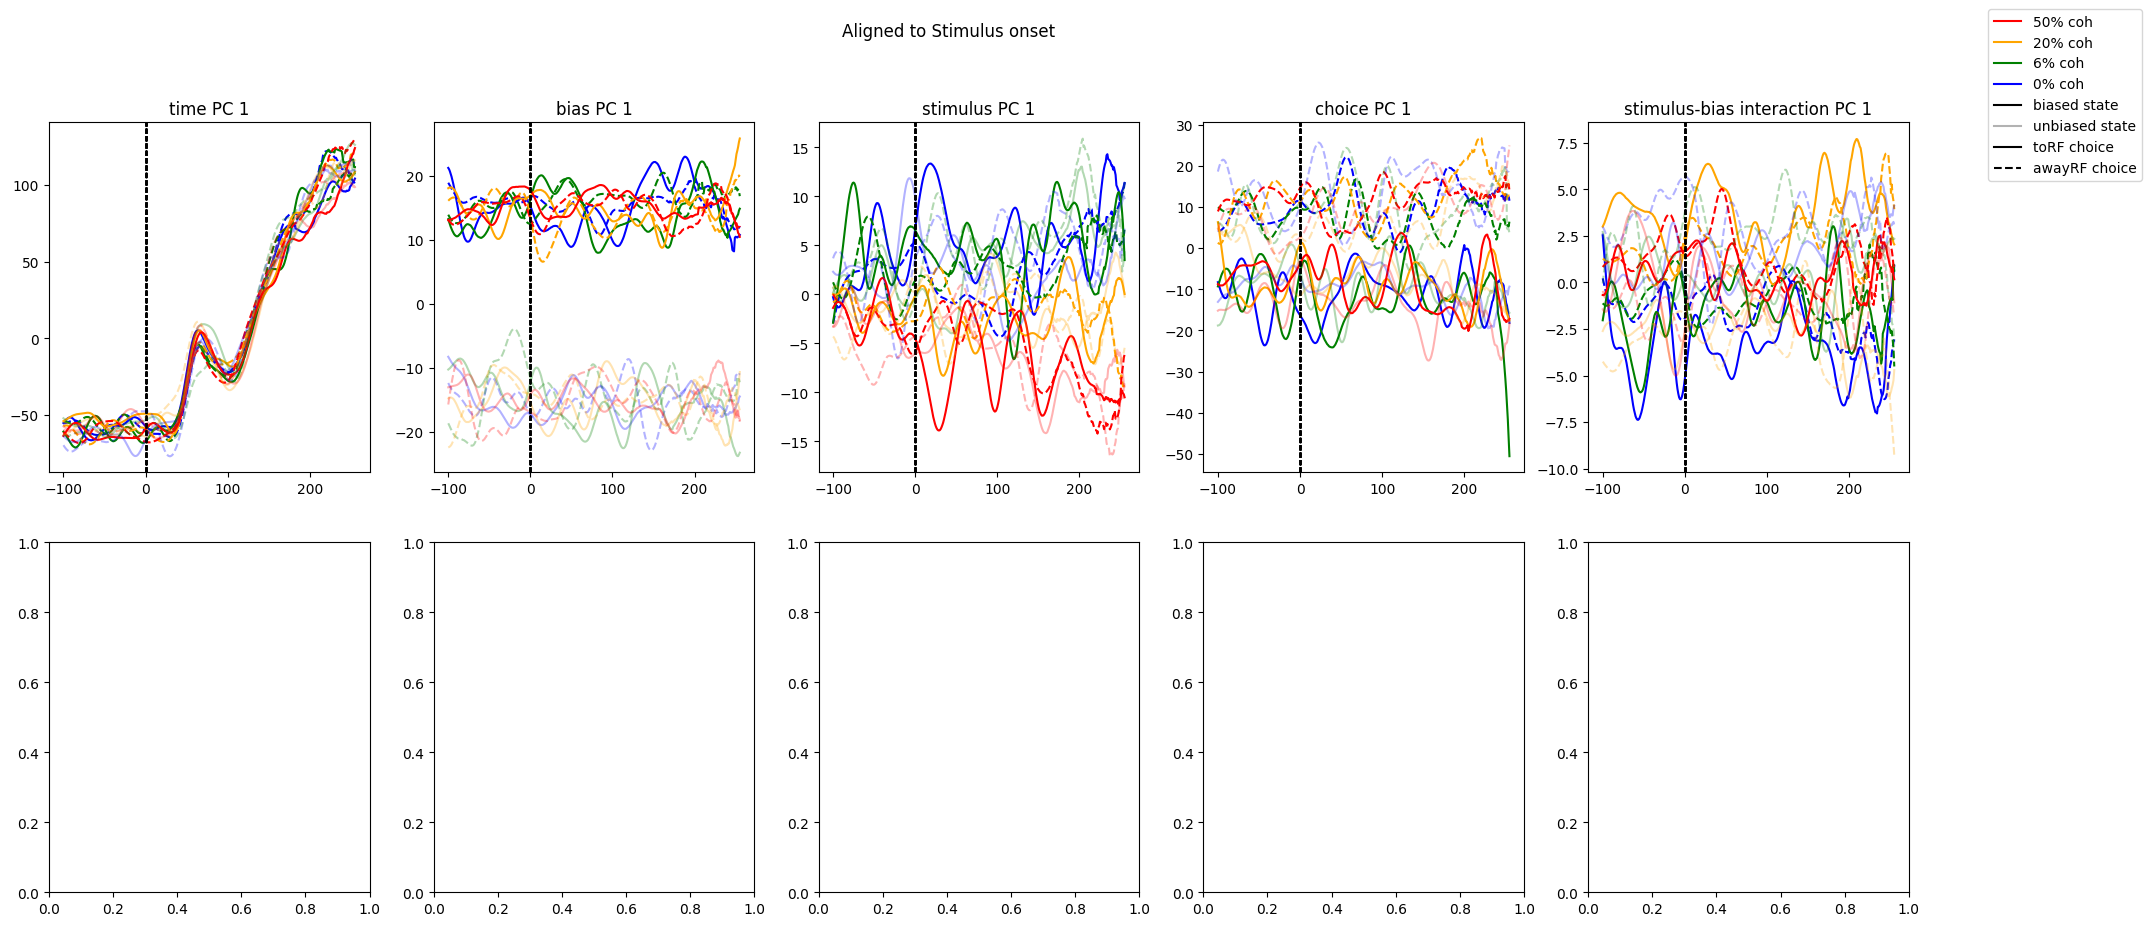

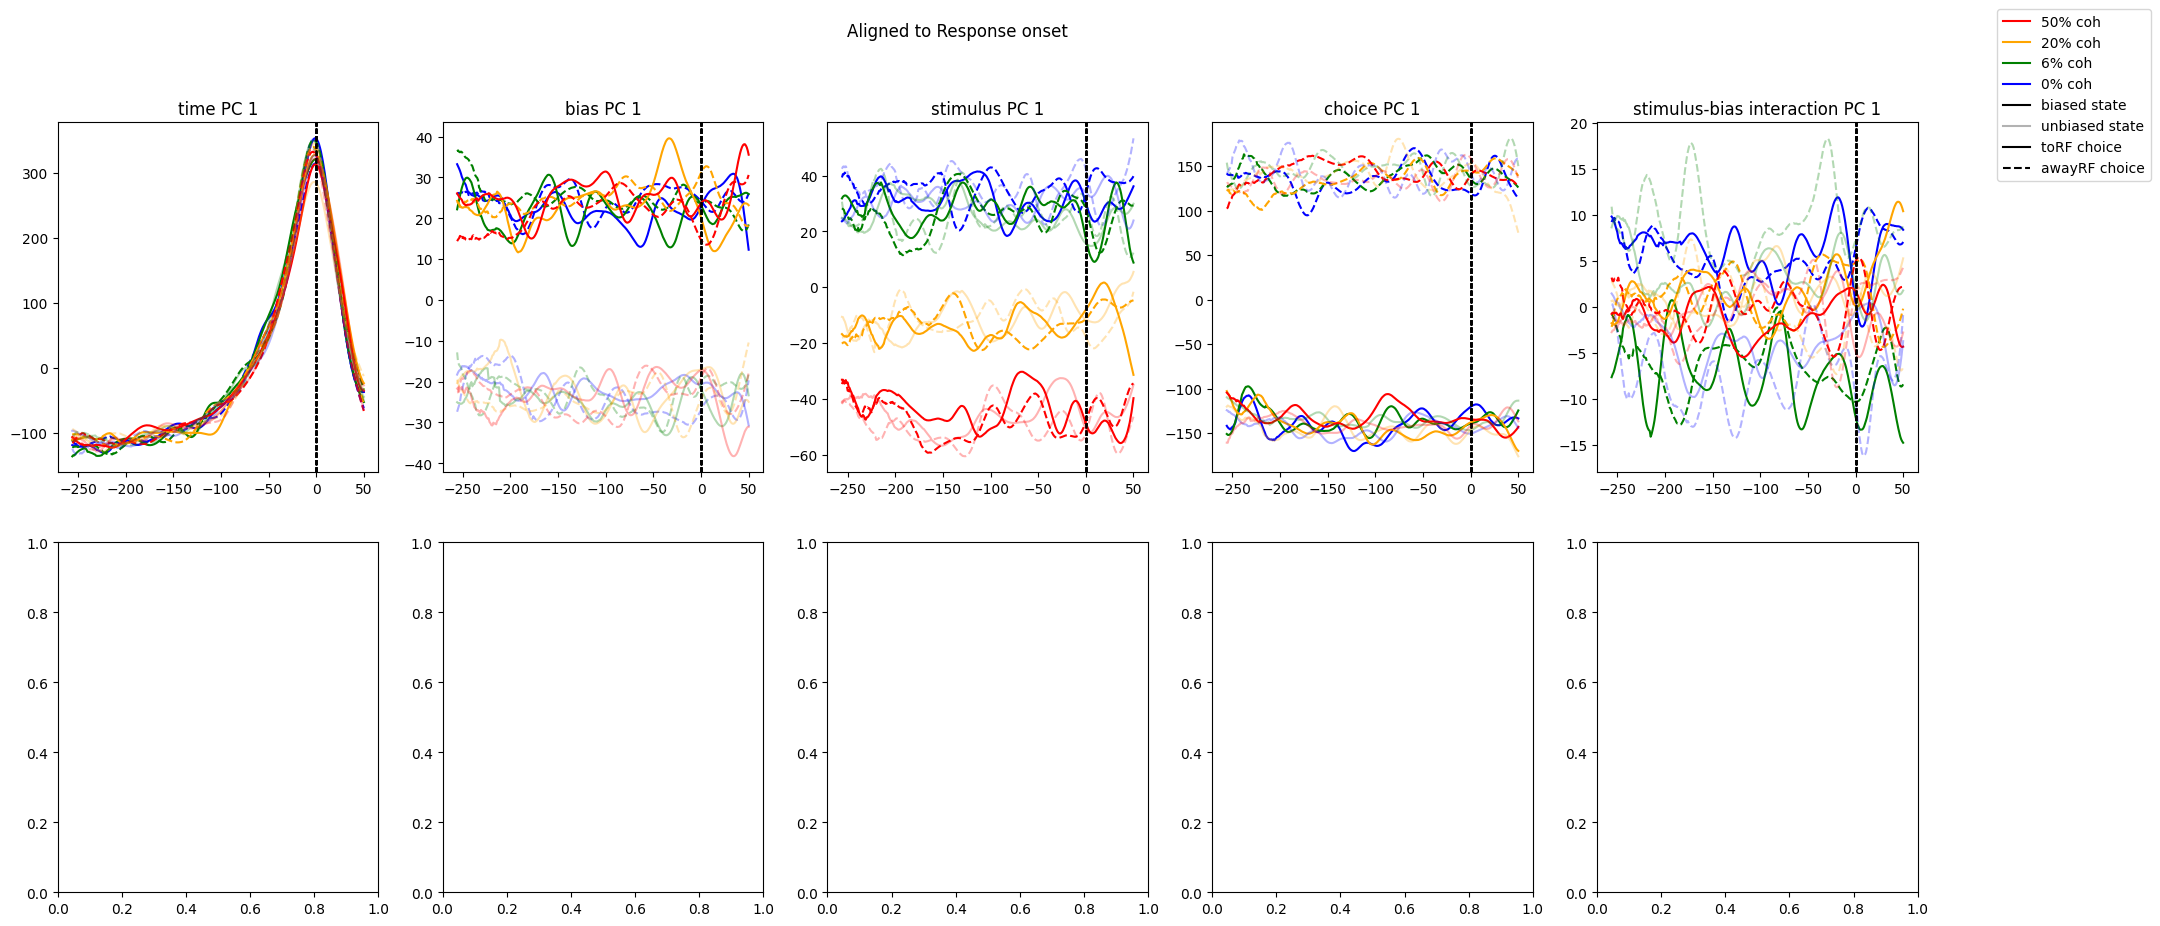

Prior: awayRF


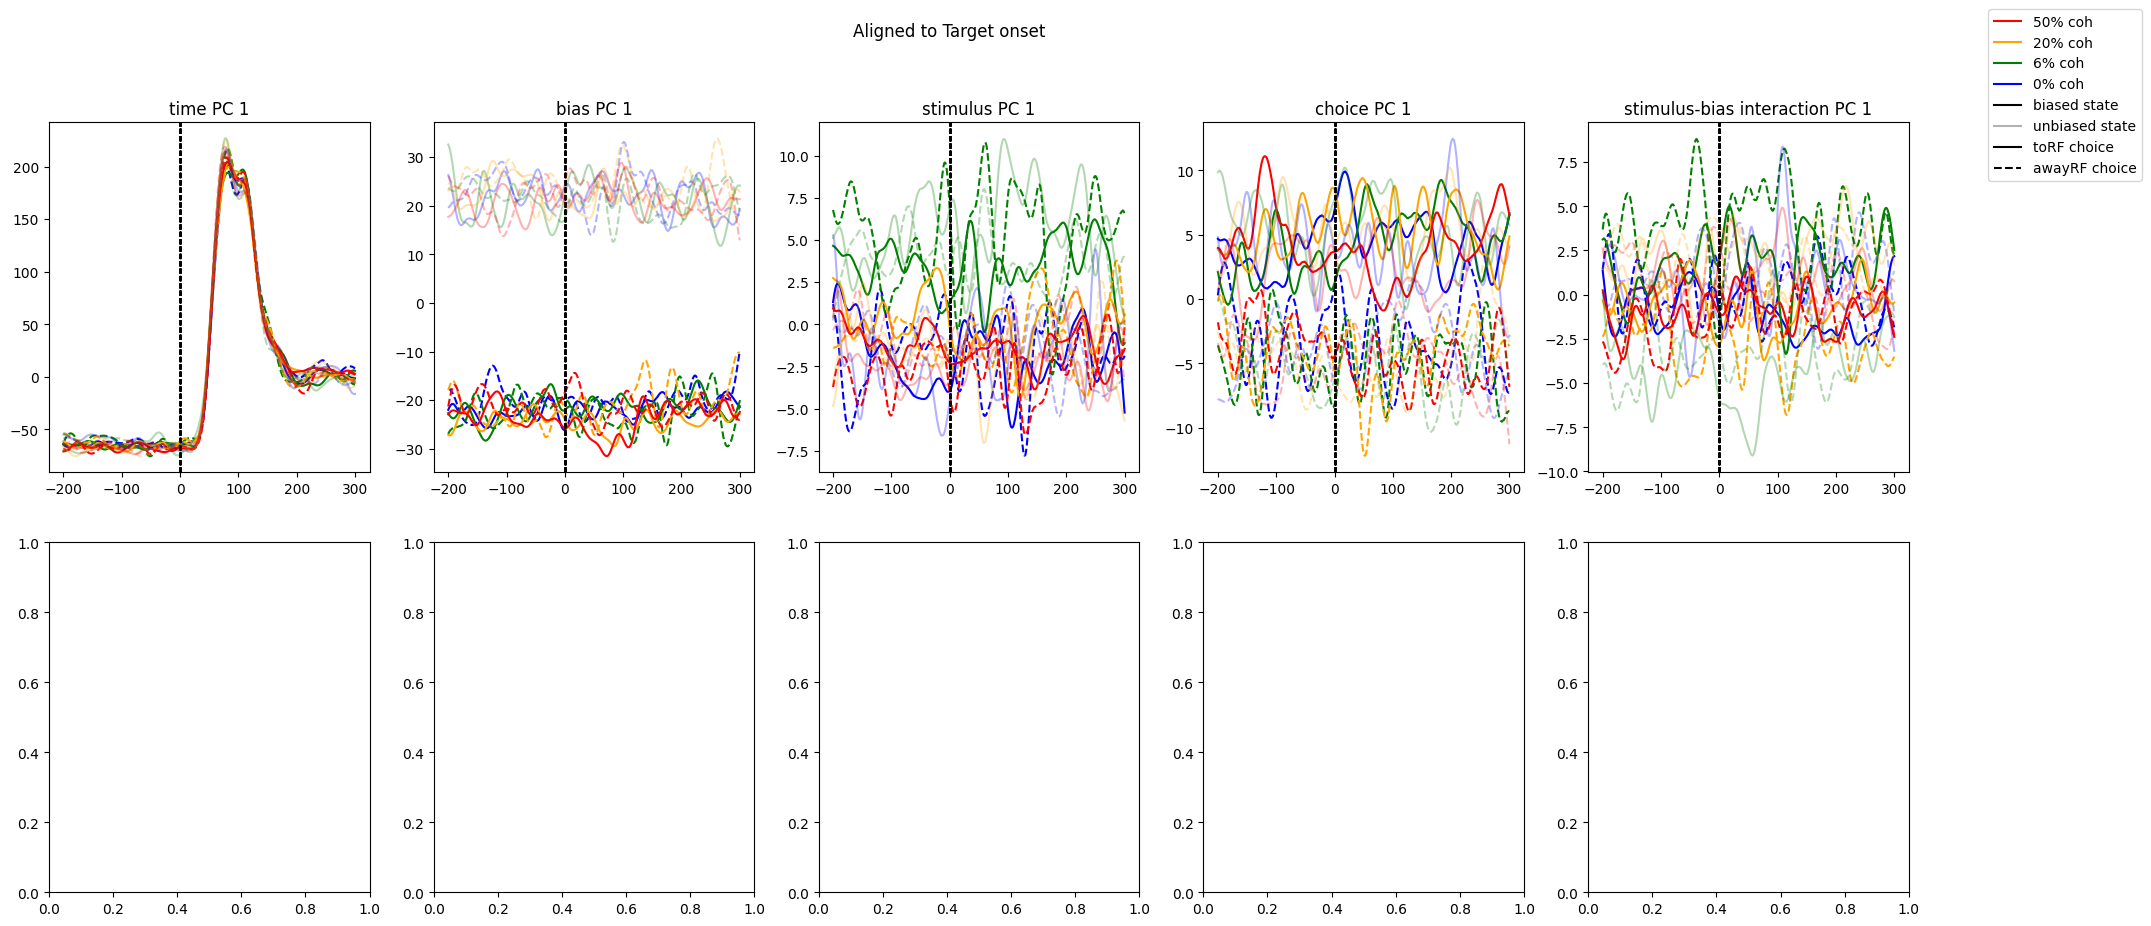

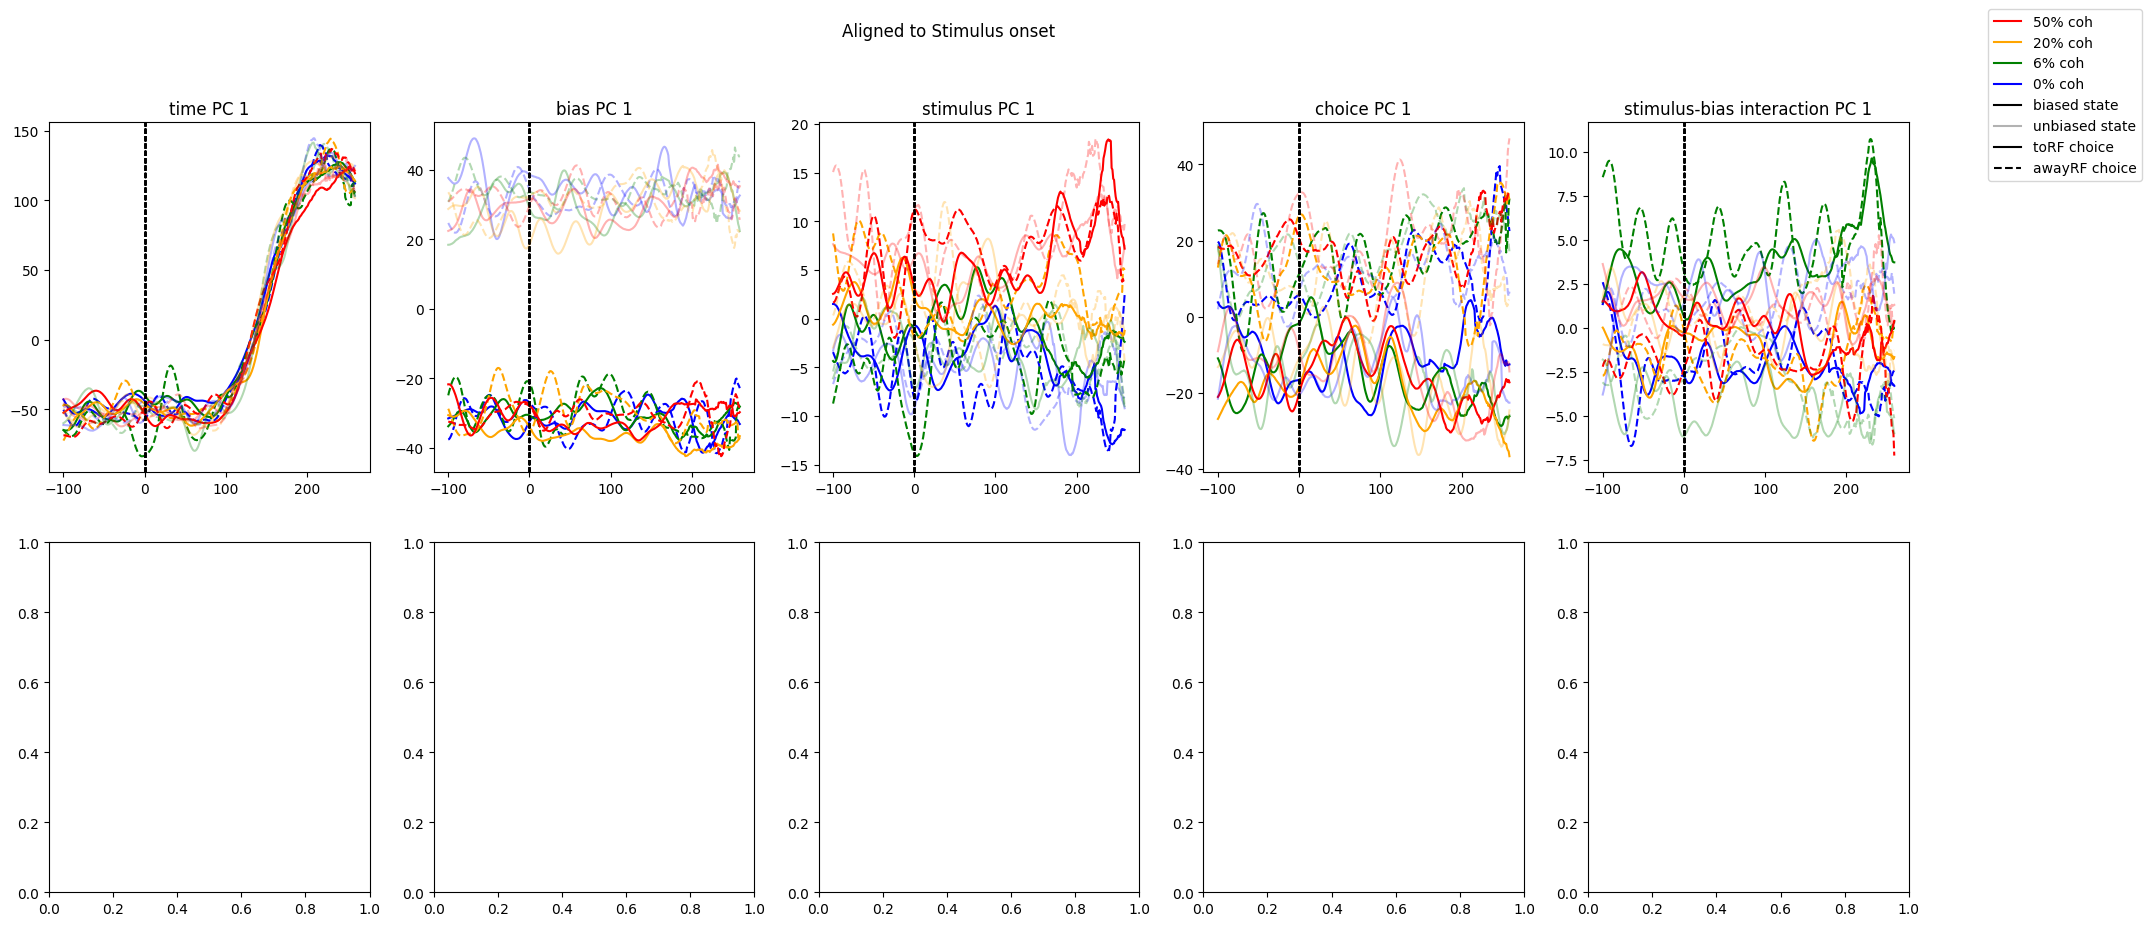

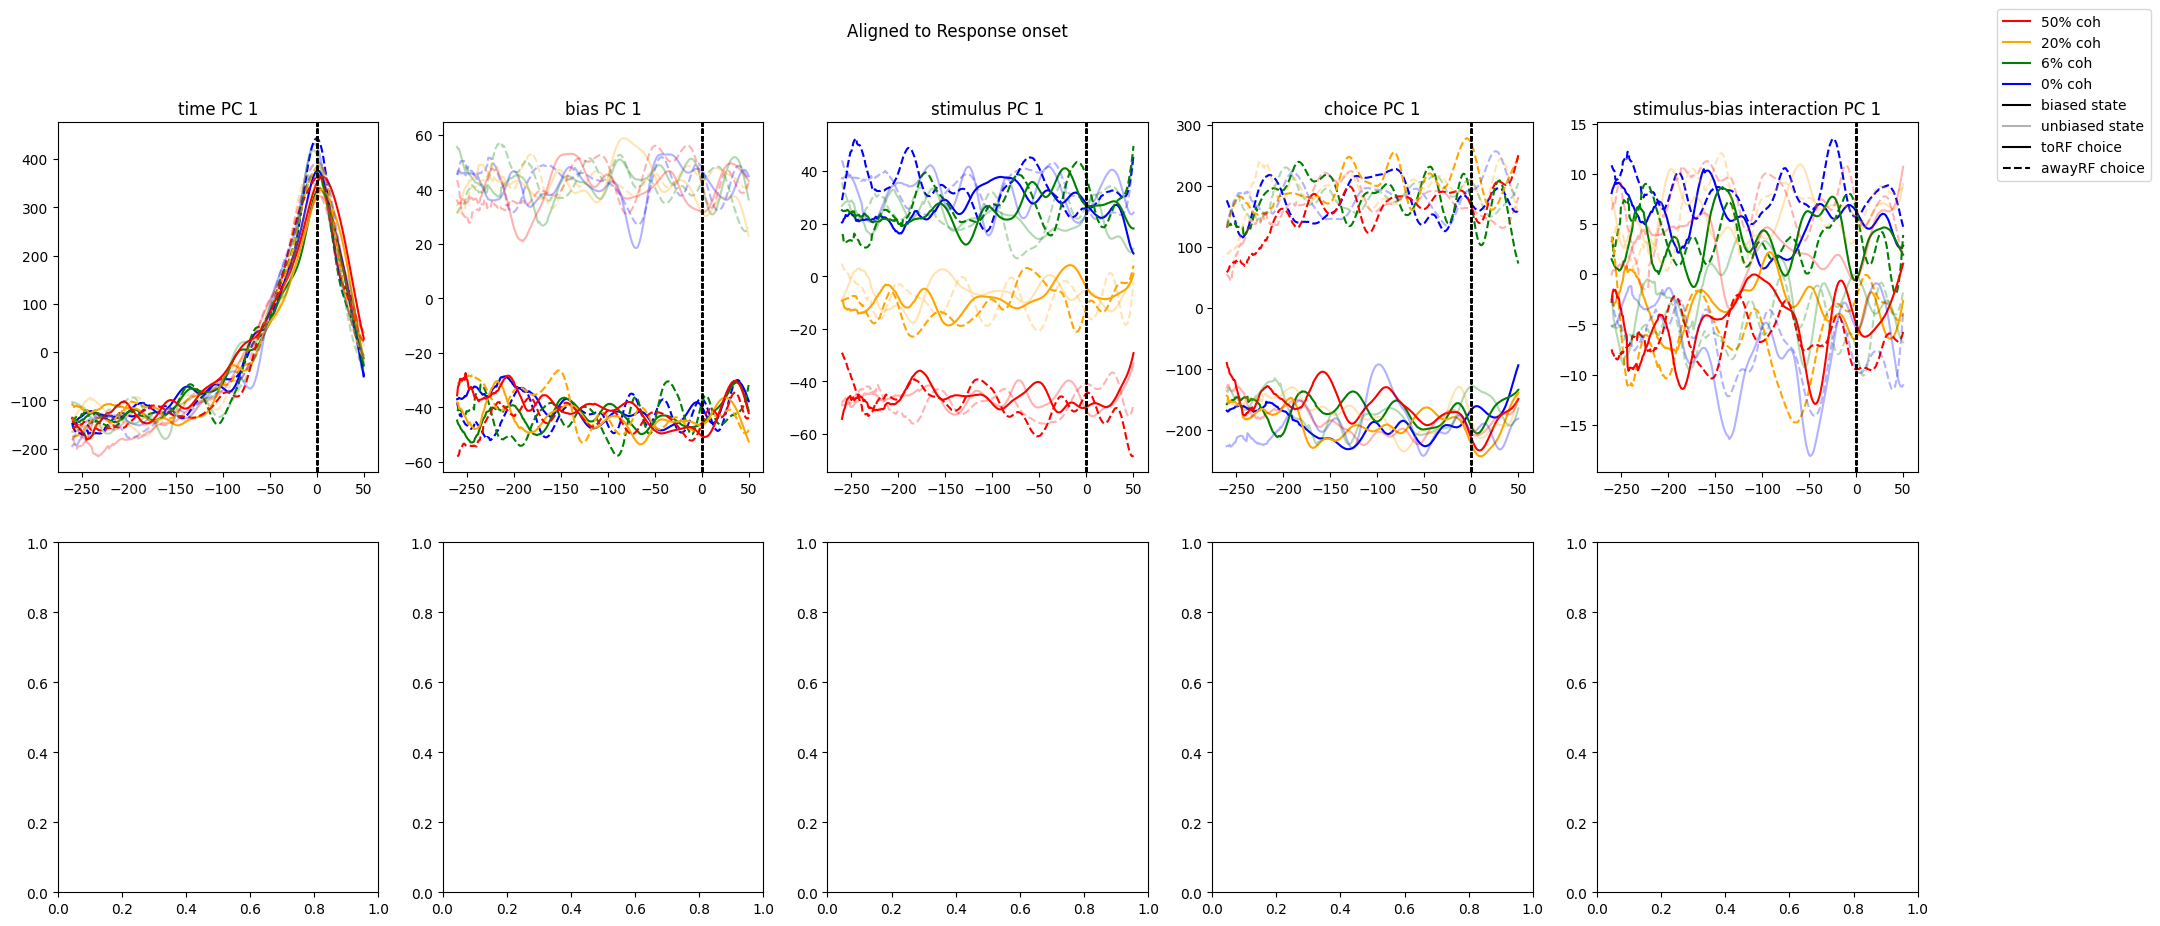

In [17]:
plot_dPCA_projection_sig(plot_mean=False, plot_sig_mask = False, prior="toRF_prior", ephys_config=ephys_config, dpca_results=dpca_projection)
plot_dPCA_projection_sig(plot_mean=False, plot_sig_mask = False, prior="awayRF_prior", ephys_config=ephys_config, dpca_results=dpca_projection)


### Significance Mask

In [ ]:
significance_masks, true_score, scores, shuffled_data = {"toRF_prior": {}, "awayRF_prior": {}},{"toRF_prior": {}, "awayRF_prior": {}},{"toRF_prior": {}, "awayRF_prior": {}}, {"toRF_prior": {}, "awayRF_prior": {}}
for prior in ["toRF_prior","awayRF_prior"]:
    print(f"Prior: {prior.split('_')[0]}")
    significance_masks[prior] = {}
    true_score[prior] = {}
    scores[prior] = {}
    shuffled_data[prior] = {}
    for alignment in ephys_config["alignment_settings_GP"]:
        significance_masks[prior][alignment], true_score[prior][alignment], scores[prior][alignment], shuffled_data[prior][alignment] = dpca_significance_analysis(
            dpca_results[prior][alignment]["model"],dPCA_averaged_data[prior][alignment], dPCA_trial_wise_data[prior][alignment], n_shuffles=100,n_splits=100, axis=True, full=True)

### whole-trial projection

In [21]:
def plot_component(ax, time, data, title=None, plot_mean=False, sig_mask=None, axes_to_loop=None, color=None, alpha=None, linestyle=None, ylim=None,lw=1):
    # Default axes to loop over if not provided (all axes: b, s, and c)
    if axes_to_loop is None:
        axes_to_loop = marginalization_keys[:-1]  # Loop over all axes: bias (b), stimulus (s), and choice (c)
    axis_indices = {marg: marg_idx for marg_idx,marg in enumerate(marginalization_keys[:-1])}
    axes_not_to_loop = [axis_indices[axis] for axis in axis_indices if axis not in axes_to_loop]


    # Loop over the specified axes (b, s, c)
    for b in np.arange(2) if 'b' in axes_to_loop else [0]:
        for s in [0,3] if 's' in axes_to_loop else [0]:
            for c in range(2) if 'c' in axes_to_loop else [0]:
                # If we are not plotting the mean, plot the raw data
                if not plot_mean:
                    ax.plot(
                        time,
                        np.squeeze(data[b, s, c, :]),  # Raw data
                        color=plot_params["color"][s] if color is None else color,
                        alpha=plot_params["opacity"][b] if alpha is None else alpha,
                        linestyle=plot_params["linestyle"][c] if linestyle is None else linestyle,
                        linewidth=lw,
                    )
                else:
                    axes = {'b': b, 's': s, 'c': c}
                    indices = [axes[axis] if axis in axes_to_loop else slice(None) for axis in axis_indices]
                    index_tuple = tuple(indices) + (slice(None),)
                    mean_data = np.mean(np.squeeze(data[index_tuple]), axis=tuple(range(len(axes_not_to_loop))))
                    ax.plot(
                        time,
                        mean_data,  # Plot the mean over the non-looped axes
                        color=plot_params["color"][s] if color is None else color,
                        alpha=plot_params["opacity"][b] if alpha is None else alpha,
                        linestyle=plot_params["linestyle"][c] if linestyle is None else linestyle,
                        linewidth=lw,
                    )

                lower_ylim = np.nanmin(data)-((np.nanmax(data) - np.nanmin(data))*0.05)-0.05
                upper_ylim = np.nanmax(data) + ((np.nanmax(data) - np.nanmin(data))*0.05)+0.05
                if sig_mask is not None:
                    ax.imshow(sig_mask, extent=[time[0], time[-1], lower_ylim, np.amin(data)-0.05], aspect='auto', cmap='gray_r', vmin=0, vmax=1)
                ax.set_title(title)
                ax.set_ylim(ylim) if ylim else ax.set_ylim(lower_ylim, upper_ylim)
                ax.axvline(0, color="black", linestyle="--", linewidth=1)

def plot_single_pc_projection(dpca_axis, prior, dpca_results, pc_component=0, ylim=None, legend=False, axes_to_loop=None, color=None,lw=1, title=None):
    print(f"Prior: {prior.split('_')[0]}")
    PC_num = pc_component
    alignment_dict = ephys_config["alignment_settings_GP"]
    alignment_fields = ["stimulus_onset", "response_onset"]

    fig, ax = plt.subplots(1, len(alignment_fields), figsize = (5*len(alignment_fields), 5))
    for idx, alignment in enumerate(alignment_fields):
        # Get transformed data
        Z = dpca_results[prior][alignment]
        sig_mask = None #significance_masks[prior][alignment] if plot_sig_mask else None

        # Align the duration based on the alignment type
        aligned_duration = np.arange(alignment_dict[alignment]["start_time_ms"], alignment_dict[alignment]["end_time_ms"] + 1)
        time = aligned_duration[-np.arange(Z['t'].shape[-1]) - 1][::-1] if alignment == "response_onset" else aligned_duration[np.arange(Z['t'].shape[-1])]
        # Set step size based on alignment type
        step = 50 if alignment == "response_onset" else 100

        x = time
        if dpca_axis == 'time':
            y, label,axes_to_loop = Z['t'][PC_num,:], f"time for PC {PC_num+1}", None
        elif dpca_axis == 'bias':
            y, label, axes_to_loop = Z['b'][PC_num, :], f"bias PC {PC_num+1}", 'b' if axes_to_loop is None else axes_to_loop
        elif dpca_axis == "stimulus":
            y, label, axes_to_loop = Z['s'][PC_num, :], f"stimulus PC {PC_num+1}", 's' if axes_to_loop is None else axes_to_loop
        elif dpca_axis == 'choice':
            y, label, axes_to_loop = Z['c'][PC_num, :], f"choice PC {PC_num+1}", 'c' if axes_to_loop is None else axes_to_loop
        elif dpca_axis == 'stimulus-bias':
            y, label, axes_to_loop = Z['bs'][PC_num, :], f"stimulus-bias interaction PC {PC_num+1}", ['b', 's'] if axes_to_loop is None else axes_to_loop
        elif dpca_axis == 'choice-bias':
            y, label, axes_to_loop = Z['bc'][PC_num, :], f"choice-bias interaction PC {PC_num+1}", ['b', 'c'] if axes_to_loop is None else axes_to_loop
        if idx < 2:
            plot_component(ax[idx], x, y, ylim=ylim, plot_mean=True, axes_to_loop=axes_to_loop, color=color,lw=lw)
        # else:
        #     plot_component(ax[idx], x, y, plot_mean=True, axes_to_loop=axes_to_loop, color=color,lw=lw)
        ax[idx].set_xlabel(alignment.capitalize().replace('_', ' '))
        ax[idx].spines['right'].set_visible(False)
        ax[idx].spines['top'].set_visible(False)

    ax[1].set_yticks([])
    ax[1].spines['left'].set_visible(False)
    ax[0].set_ylabel(f"Projection onto {dpca_axis.capitalize()} PC {PC_num+1} (a.u.)")

    if legend:
        # Add the legend for different lines
        handles = [
            plt.Line2D([0], [0], color="red", label="50% coh"),
            plt.Line2D([0], [0], color="orange", label="20% coh"),
            plt.Line2D([0], [0], color="green", label="6% coh"),
            plt.Line2D([0], [0], color="blue", label="0% coh"),
            plt.Line2D([0], [0], color='k', alpha=1, label="biased state"),
            plt.Line2D([0], [0], color='k', alpha=0.3, label="unbiased state"),
            plt.Line2D([0], [0], color='k', linestyle="-", label="toRF choice"),
            plt.Line2D([0], [0], color='k', linestyle="--", label="awayRF choice"),
        ]
        fig.legend(handles=handles, bbox_to_anchor=(1, 1), loc='upper right')

    fig.suptitle(f"Projection of {title} {dpca_axis.capitalize()} Component Across Task Epochs")
    plt.show()

Prior: toRF


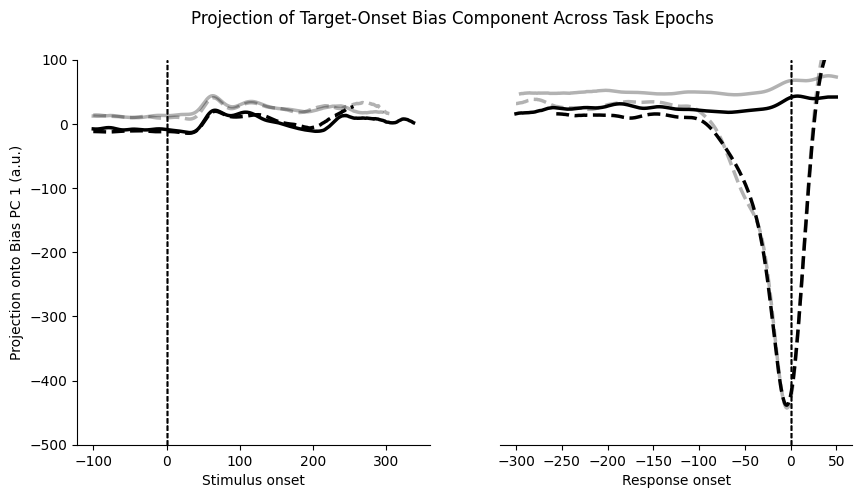

Prior: toRF


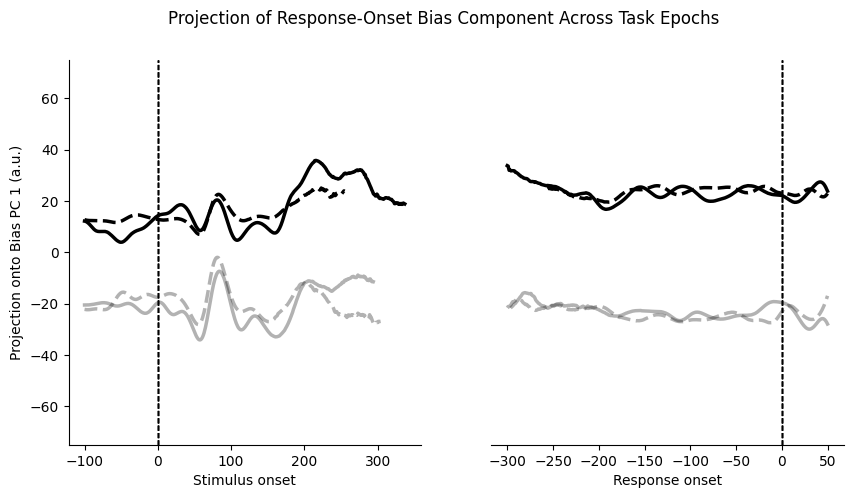

In [22]:
dpca_axis = "bias"
dpca_results = target_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="toRF_prior", dpca_results=dpca_results, legend=False, ylim=(-500, 100),axes_to_loop=['b', 'c'], color='k', lw=2.5,title='Target-Onset')
dpca_results = response_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="toRF_prior", dpca_results=dpca_results, legend=False,lw=2.5,title='Response-Onset', ylim=(-75,75), axes_to_loop=['b', 'c'], color='k')

Prior: toRF


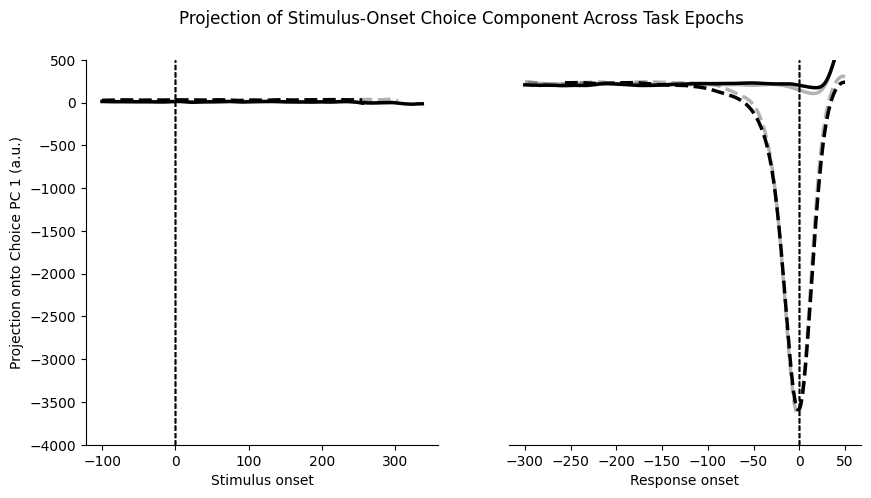

Prior: toRF


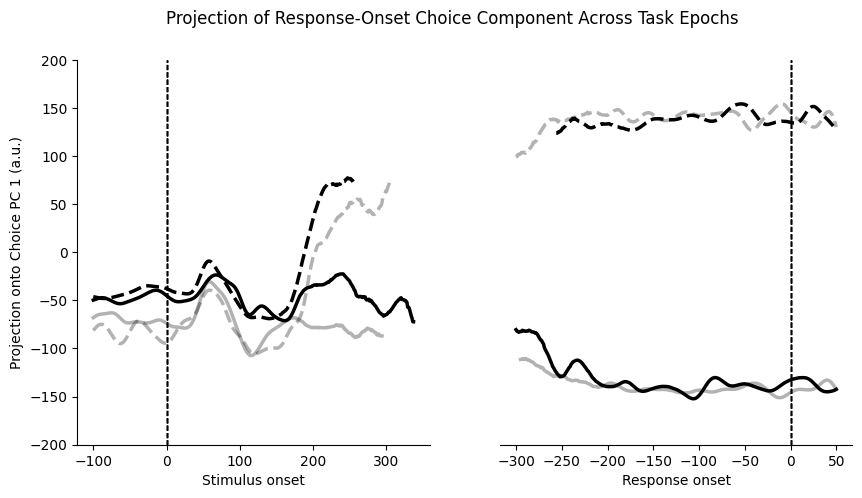

In [23]:
dpca_axis = "choice"
dpca_results = stimulus_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="toRF_prior", dpca_results=dpca_results, legend=False, ylim=(-4000, 500),axes_to_loop=['b', 'c'], color='k', lw=2.5,title='Stimulus-Onset')
dpca_results = response_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="toRF_prior", dpca_results=dpca_results, legend=False,lw=2.5,title='Response-Onset', ylim=(-200,200), axes_to_loop=['b', 'c'], color='k')

Prior: toRF


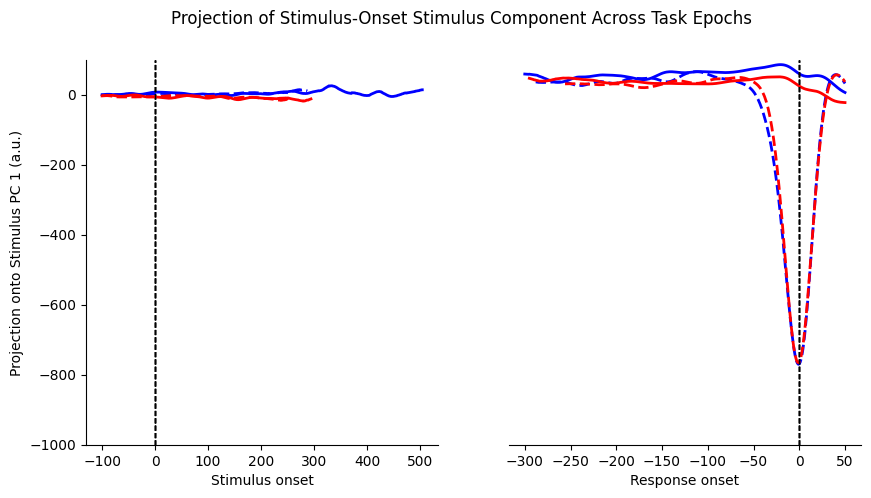

Prior: toRF


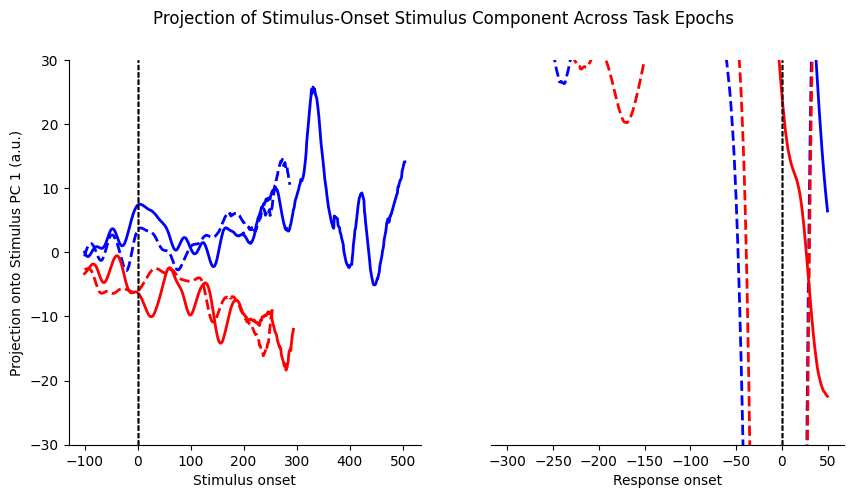

Prior: toRF


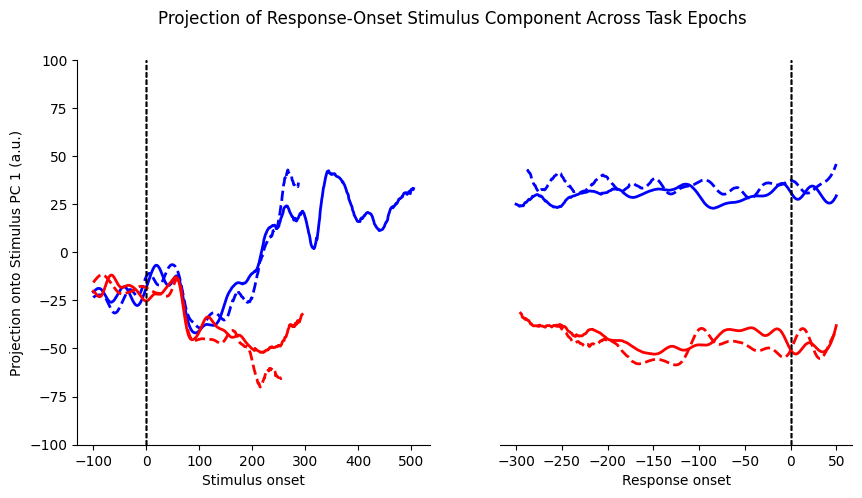

In [24]:
dpca_axis = "stimulus"
dpca_results = stimulus_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="toRF_prior", dpca_results=dpca_results, legend=False, ylim=(-1000, 100), lw=2,title='Stimulus-Onset',axes_to_loop=['s', 'c'])
plot_single_pc_projection(dpca_axis=dpca_axis, prior="toRF_prior", dpca_results=dpca_results, legend=False, ylim=(-30, 30), lw=2,title='Stimulus-Onset',axes_to_loop=['s','c'])
dpca_results = response_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="toRF_prior", dpca_results=dpca_results, legend=False,lw=2,title='Response-Onset', ylim=(-100,100),axes_to_loop=['s','c'])

### awayRF

Prior: awayRF


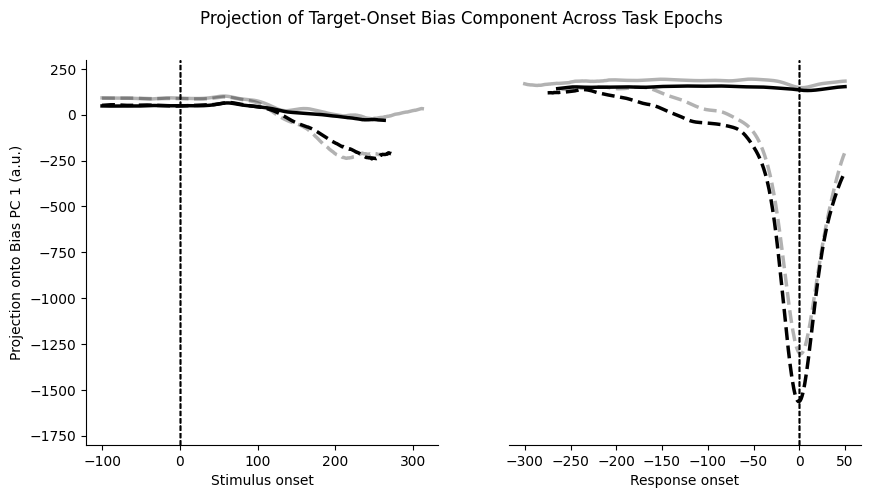

Prior: awayRF


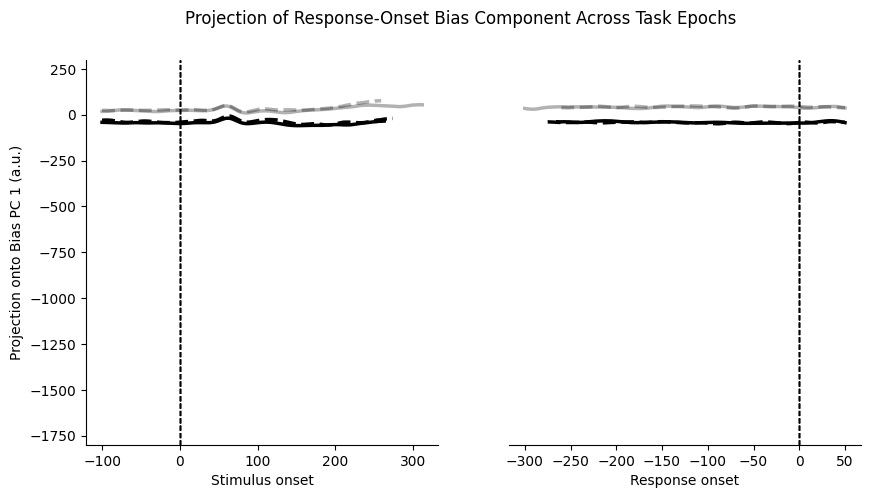

In [25]:
dpca_axis = "bias"
dpca_results = target_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False, ylim=(-1800, 300),axes_to_loop=['b', 'c'], color='k', lw=2.5,title='Target-Onset')
dpca_results = response_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False,lw=2.5,title='Response-Onset', ylim=(-1800, 300), axes_to_loop=['b', 'c'], color='k')

Prior: awayRF


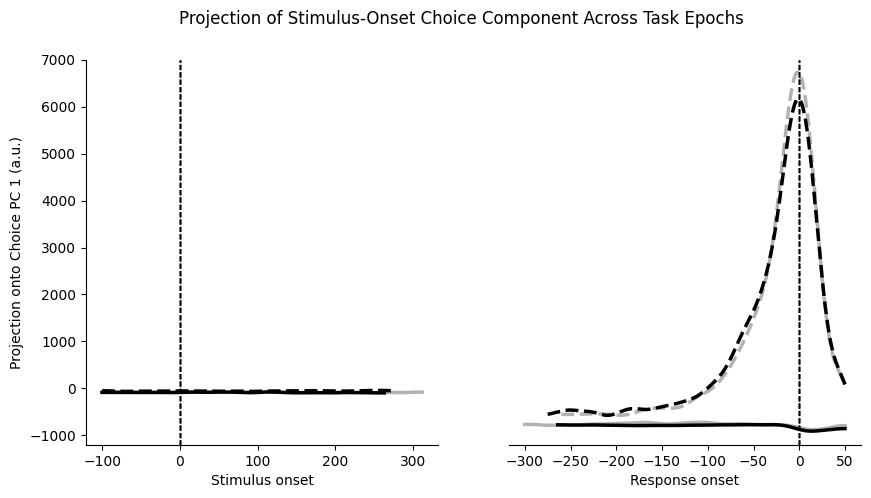

Prior: awayRF


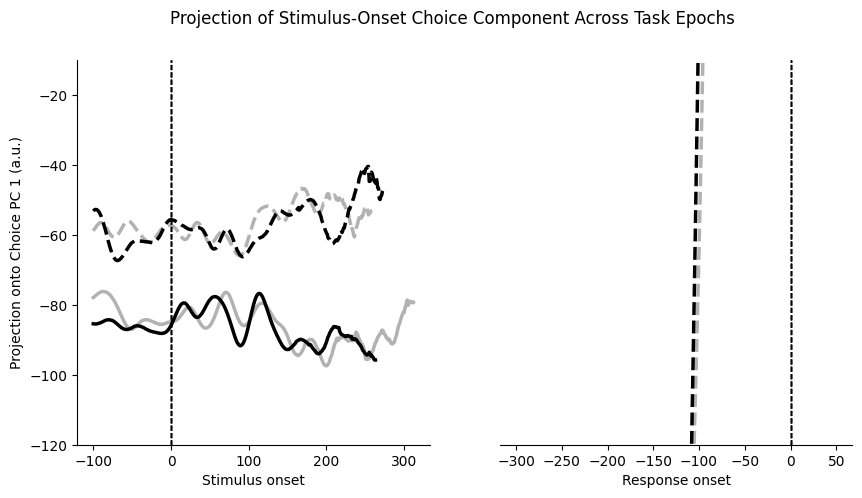

Prior: awayRF


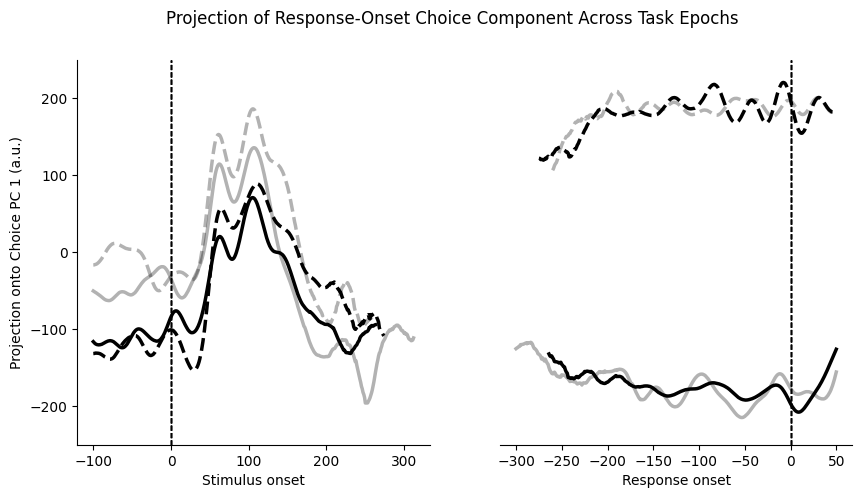

In [26]:
dpca_axis = "choice"
dpca_results = stimulus_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False, ylim=(-1200, 7000),axes_to_loop=['b', 'c'], color='k', lw=2.5,title='Stimulus-Onset')
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False, ylim=(-120, -10),axes_to_loop=['b', 'c'], color='k', lw=2.5,title='Stimulus-Onset')
dpca_results = response_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False,lw=2.5,title='Response-Onset', ylim=(-250,250), axes_to_loop=['b', 'c'], color='k')

Prior: awayRF


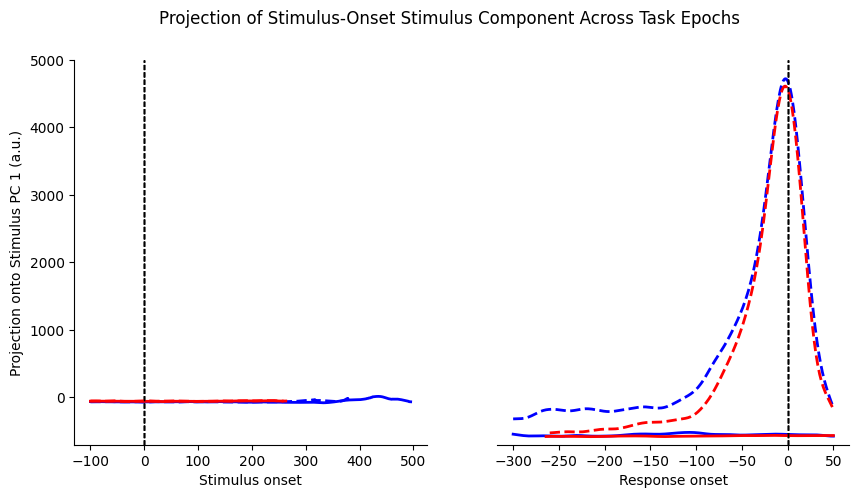

Prior: awayRF


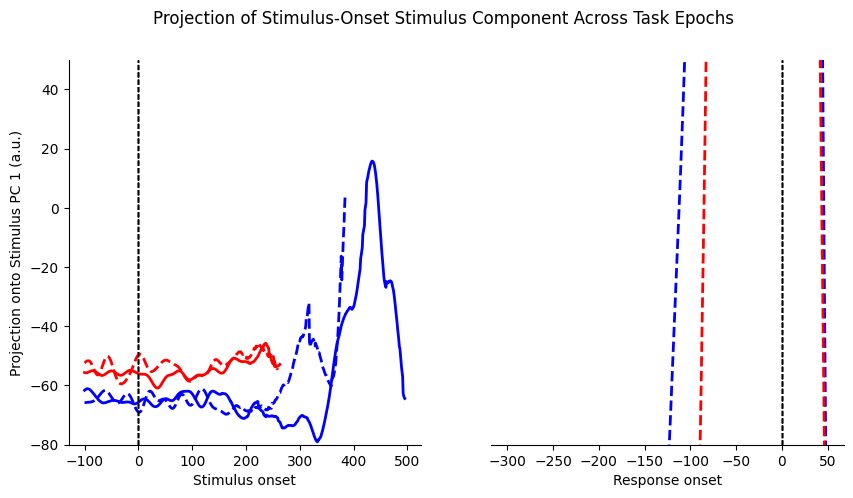

Prior: awayRF


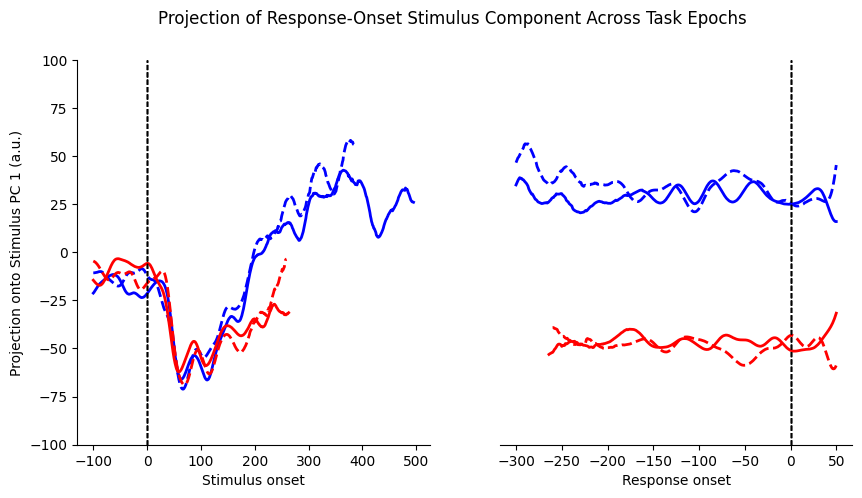

In [27]:
dpca_axis = "stimulus"
dpca_results = stimulus_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False, ylim=(-700, 5000), lw=2,title='Stimulus-Onset',axes_to_loop=['s','c'])
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False, ylim=(-80, 50), lw=2,title='Stimulus-Onset',axes_to_loop=['s','c'])
dpca_results = response_onset_projection
plot_single_pc_projection(dpca_axis=dpca_axis, prior="awayRF_prior", dpca_results=dpca_results, legend=False,lw=2,title='Response-Onset', ylim=(-100,100),axes_to_loop=['s','c'])

## Neuron Selectivity

In [246]:
prior = "awayRF_prior"
awayRF_loadings = {}
for dpca_axis in ['b', 'c', 's', 'bs', 'bc', 't']:
    awayRF_loadings[dpca_axis] = []
    for alignment in align_labels:
        awayRF_loadings[dpca_axis].append(dpca_projection[alignment][prior]["model"].D[dpca_axis][:,0])
    awayRF_loadings[dpca_axis] = np.array(awayRF_loadings[dpca_axis])

prior = "toRF_prior"
toRF_loadings = {}
for dpca_axis in ['b', 'c', 's', 'bs', 'bc', 't']:
    toRF_loadings[dpca_axis] = []
    for alignment in align_labels:
        toRF_loadings[dpca_axis].append(dpca_projection[alignment][prior]["model"].D[dpca_axis][:,0])
    toRF_loadings[dpca_axis] = np.array(toRF_loadings[dpca_axis])

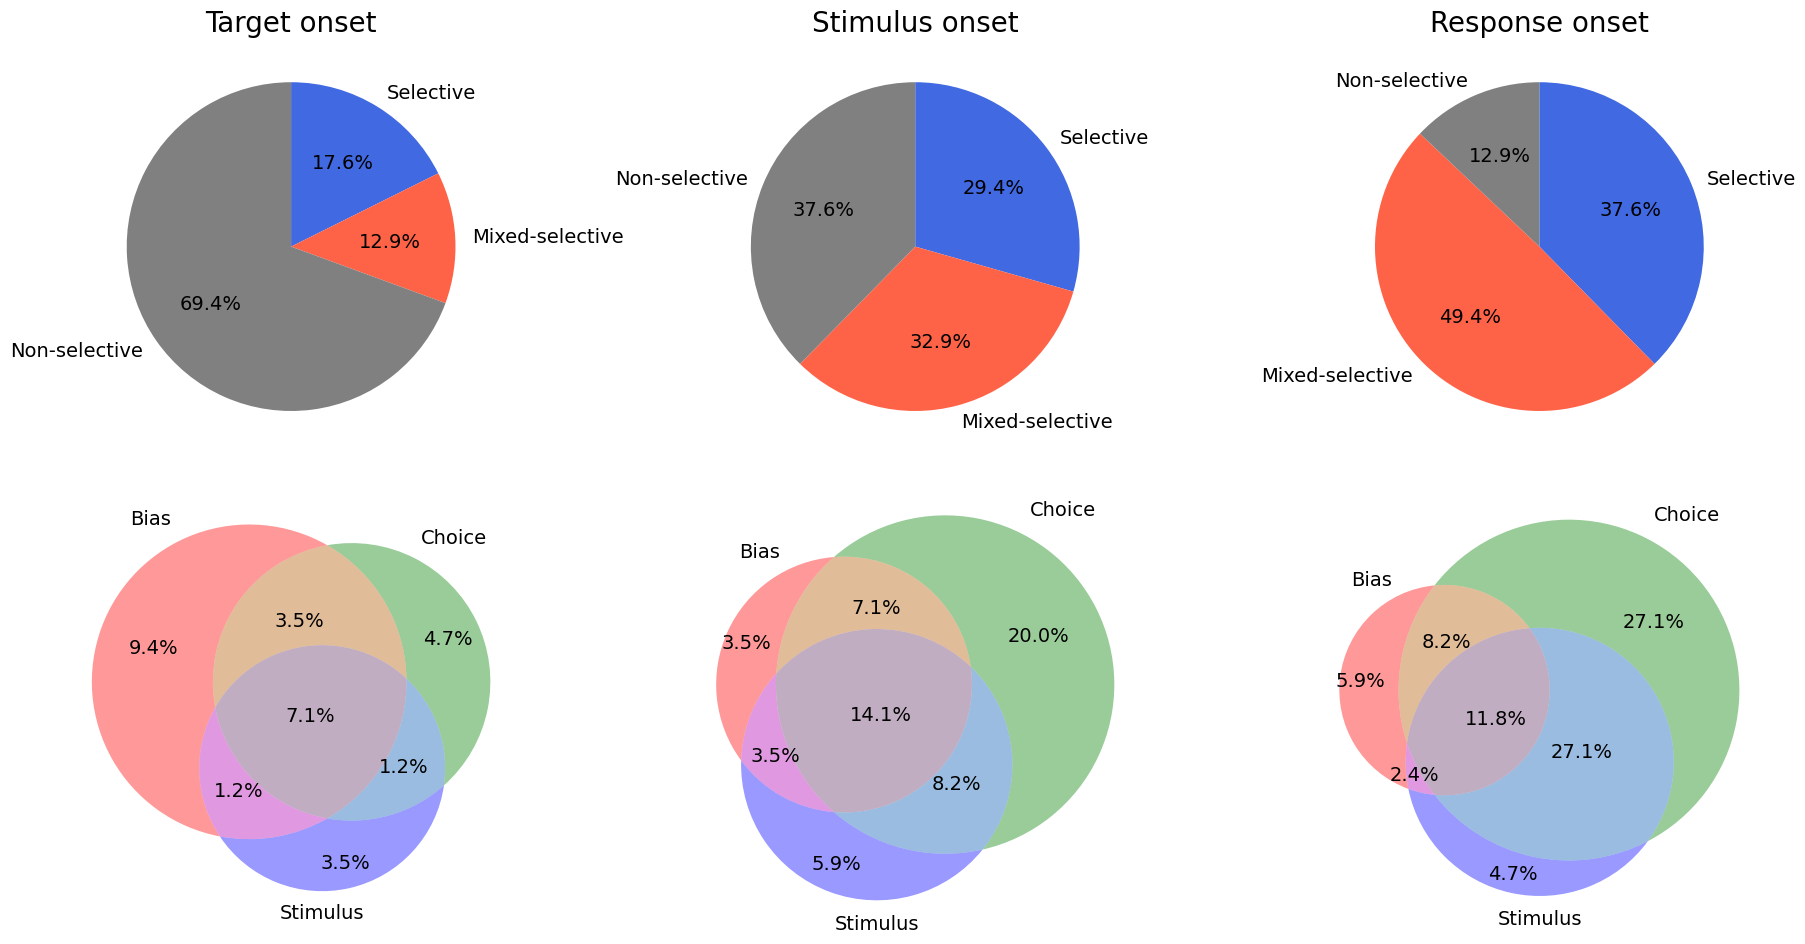

In [248]:
loadings = toRF_loadings
threshold = 0.3
total_neurons = loadings['c'].shape[1]

# Prepare summary counts for top row plots
summary_list = []

for idx, align_label in enumerate(align_labels):
    selective_neurons = 0
    mixed_neurons = 0
    nonselective_neurons = 0

    for neuron in range(total_neurons):
        vals = np.array([np.abs(loadings[axis][idx][neuron]) for axis in ['b', 'c', 's']])
        strong_axes_count = np.sum(vals > threshold)
        if strong_axes_count == 0:
            nonselective_neurons += 1
        elif strong_axes_count == 1:
            selective_neurons += 1
        else:
            mixed_neurons += 1

    summary_list.append({
        'Selective': selective_neurons,
        'Mixed-selective': mixed_neurons,
        'Non-selective': nonselective_neurons
    })

# Precompute venn data for bottom row
venn_data_list = []

for idx, align_label in enumerate(align_labels):
    b_set = set(np.where(np.abs(loadings['b'][idx]) > threshold)[0])
    c_set = set(np.where(np.abs(loadings['c'][idx]) > threshold)[0])
    s_set = set(np.where(np.abs(loadings['s'][idx]) > threshold)[0])

    venn_data = {
        '100': len(b_set - c_set - s_set),
        '010': len(c_set - b_set - s_set),
        '001': len(s_set - b_set - c_set),
        '110': len(b_set & c_set - s_set),
        '101': len(b_set & s_set - c_set),
        '011': len(c_set & s_set - b_set),
        '111': len(b_set & c_set & s_set),
        'nonselective': len(set(range(total_neurons)) - (b_set | c_set | s_set))
    }
    venn_data_list.append(venn_data)

# Create figure with 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10), gridspec_kw={'height_ratios': [1, 1.5]})

fontsize = 14  # uniform fontsize for all labels

# Top row: pie charts for selective, mixed, non-selective neurons
for idx, ax in enumerate(axes[0]):
    summary = summary_list[idx]
    labels = ['Selective', 'Mixed-selective', 'Non-selective']
    counts = [summary[label] for label in labels]
    colors = ['royalblue', 'tomato', 'gray']

    wedges, texts, autotexts = ax.pie(counts, labels=labels, autopct='%1.1f%%',
                                      colors=colors, startangle=90, counterclock=False,
                                      textprops={'fontsize': fontsize})
    for text in texts:
        text.set_fontsize(fontsize)
    for autotext in autotexts:
        autotext.set_fontsize(fontsize)

    ax.set_title(f"{list(align_labels.keys())[idx].replace('_',' ').capitalize()}", fontsize=fontsize+6, pad=25)
    ax.axis('equal')  # Equal aspect ratio ensures pie is a circle

# Bottom row: venn diagrams
for idx, ax in enumerate(axes[1]):
    data = venn_data_list[idx]

    subset_sizes = (data['100'], data['010'], data['110'],
                    data['001'], data['101'], data['011'], data['111'])

    v = venn3(subsets=subset_sizes, set_labels=('Bias', 'Choice', 'Stimulus'), ax=ax)

    # Set font size for subset labels
    for subset_id in ('100', '010', '110', '001', '101', '011', '111'):
        label = v.get_label_by_id(subset_id)
        if label:
            count = data[subset_id]
            label.set_text(f"{100 * count / total_neurons:.1f}%")
            label.set_fontsize(fontsize)

    # Set font size for set labels
    for set_label in v.set_labels:
        if set_label:
            set_label.set_fontsize(fontsize)

    ax.set_aspect('equal')  # Make sure venn diagram is circular

plt.tight_layout()
plt.show()


### loading heatmap

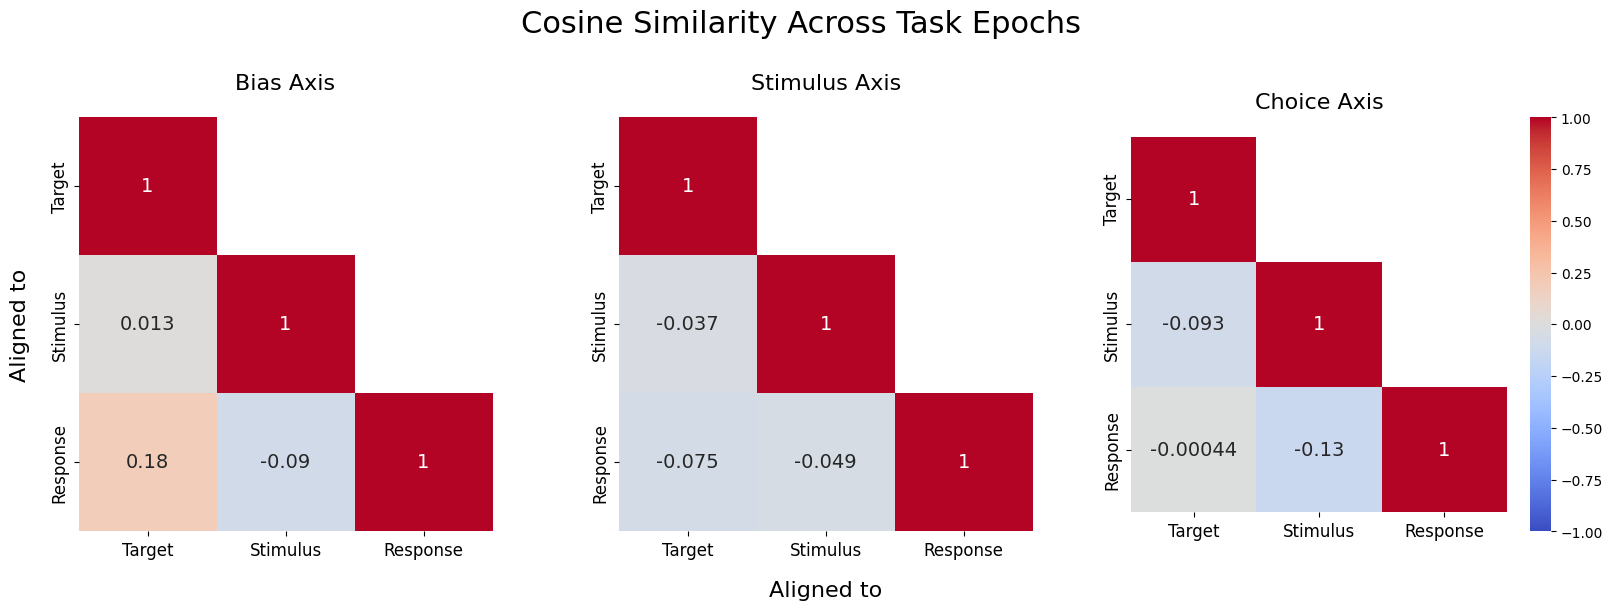

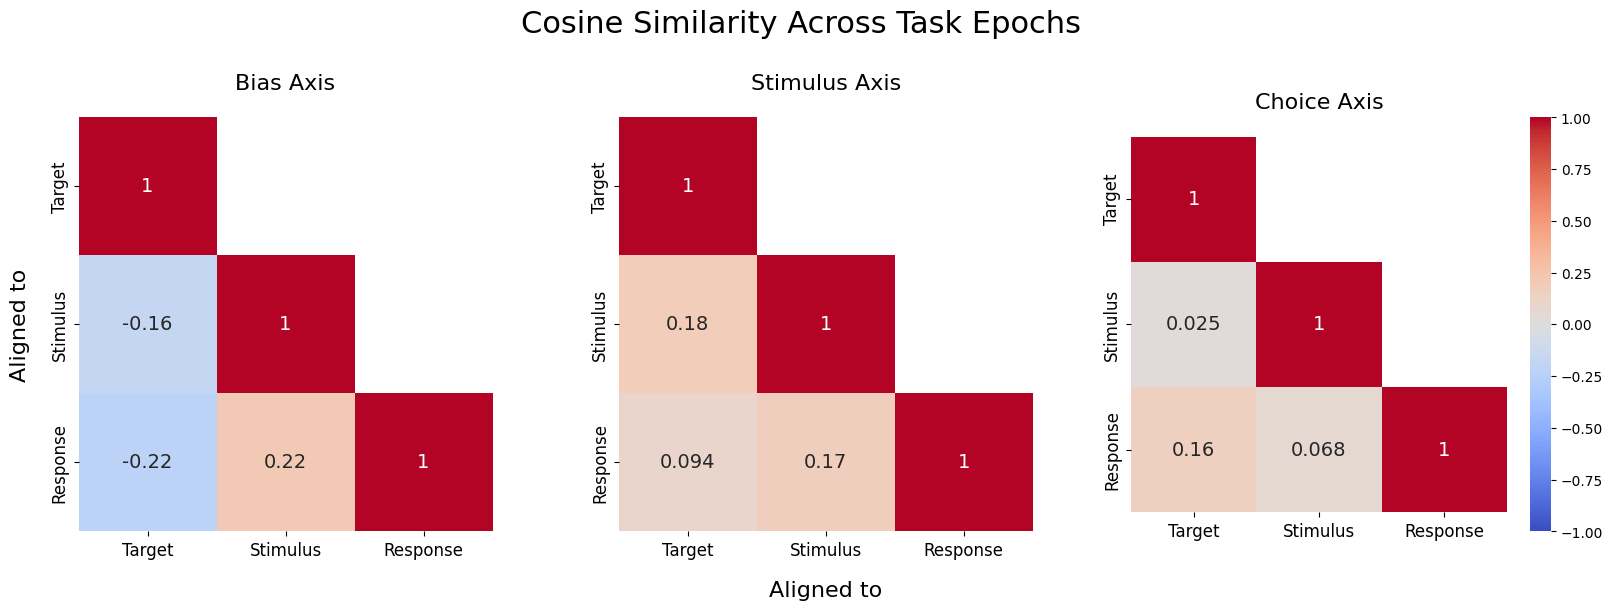

In [253]:
def pairwise_cosine_similarity(vecs):
    n = len(vecs)
    sim = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            sim[i, j] = 1 - cosine(vecs[i], vecs[j])
    return sim

similarity_matrix = {"toRF": [], "awayRF": []}

loadings = awayRF_loadings
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
dpca_axes = ['b', 's', 'c']

for idx, dpca_ax in enumerate(dpca_axes):
    similarity_matrix["awayRF"].append(pairwise_cosine_similarity(loadings[dpca_ax]))
    # Mask lower triangle and diagonal
    mask = np.triu(np.ones_like(similarity_matrix["awayRF"][idx], dtype=bool), k=1)
    sns.heatmap(similarity_matrix["awayRF"][idx],
                annot=True,
                annot_kws={"size": 14},
                xticklabels=[align_label.split('_')[0].capitalize() for align_label in align_labels],
                yticklabels=[align_label.split('_')[0].capitalize() for align_label in align_labels],
                cmap='coolwarm',
                vmin=-1,
                vmax=1,
                square=True,
                mask=mask,
                cbar=(idx == len(dpca_axes) - 1),  # only last subplot has colorbar
                ax=axs[idx])

    axs[idx].tick_params(axis='x', labelsize=12)
    axs[idx].tick_params(axis='y', labelsize=12)
    axs[idx].set_title(f"{marginalization[dpca_ax]} Axis",
                       fontsize=16, pad=20)
axs[0].set_ylabel("Aligned to", fontsize=16, labelpad=15)
axs[1].set_xlabel("Aligned to", fontsize=16, labelpad=15)

plt.suptitle("Cosine Similarity Across Task Epochs", fontsize=22)
plt.subplots_adjust(top=0.80, wspace=0.15)
# plt.tight_layout()
plt.show()

loadings = toRF_loadings
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
dpca_axes = ['b', 's', 'c']
for idx, dpca_ax in enumerate(dpca_axes):
    similarity_matrix["toRF"].append(pairwise_cosine_similarity(loadings[dpca_ax]))
    # Mask lower triangle and diagonal
    mask = np.triu(np.ones_like(similarity_matrix["toRF"][idx], dtype=bool), k=1)
    sns.heatmap(similarity_matrix["toRF"][idx],
                annot=True,
                annot_kws={"size": 14},
                xticklabels=[align_label.split('_')[0].capitalize() for align_label in align_labels],
                yticklabels=[align_label.split('_')[0].capitalize() for align_label in align_labels],
                cmap='coolwarm',
                vmin=-1,
                vmax=1,
                square=True,
                mask=mask,
                cbar=(idx == len(dpca_axes) - 1),  # only last subplot has colorbar
                ax=axs[idx])

    axs[idx].tick_params(axis='x', labelsize=12)
    axs[idx].tick_params(axis='y', labelsize=12)
    axs[idx].set_title(f"{marginalization[dpca_ax]} Axis",
                       fontsize=16, pad=20)
axs[0].set_ylabel("Aligned to", fontsize=16, labelpad=15)
axs[1].set_xlabel("Aligned to", fontsize=16, labelpad=15)

plt.suptitle("Cosine Similarity Across Task Epochs", fontsize=22)
plt.subplots_adjust(top=0.80, wspace=0.15)
# plt.tight_layout()
plt.show()


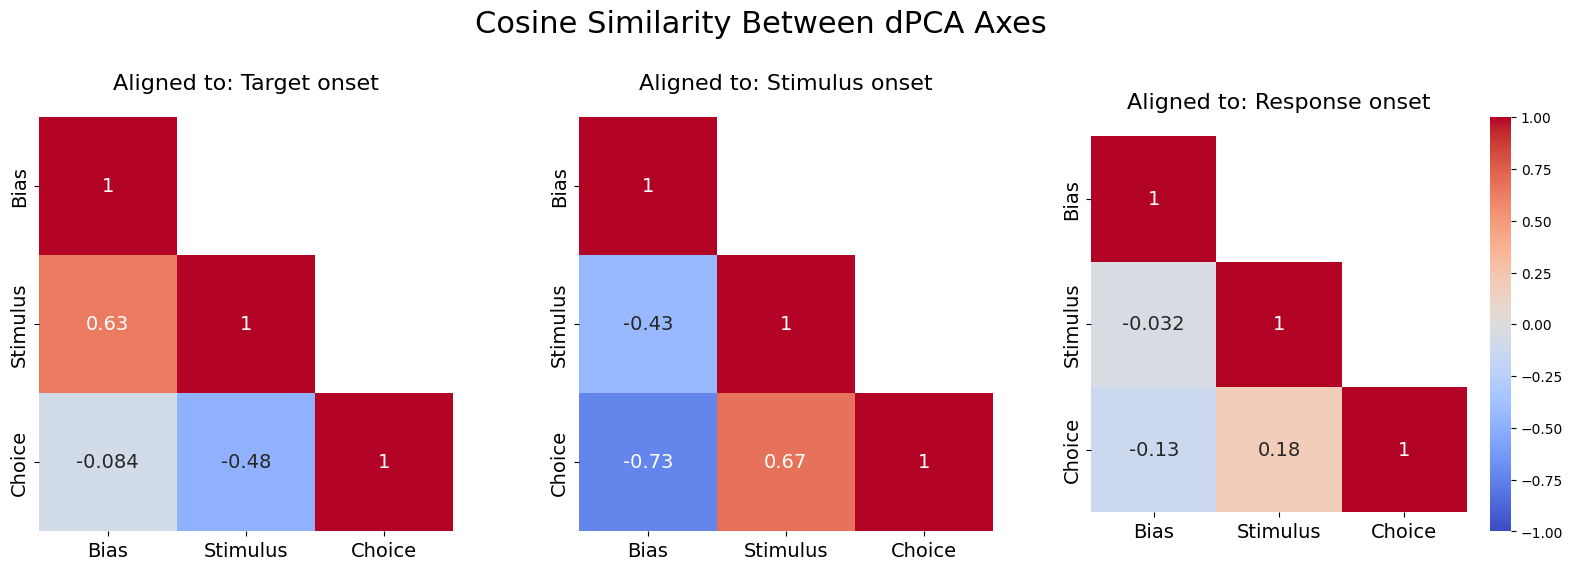

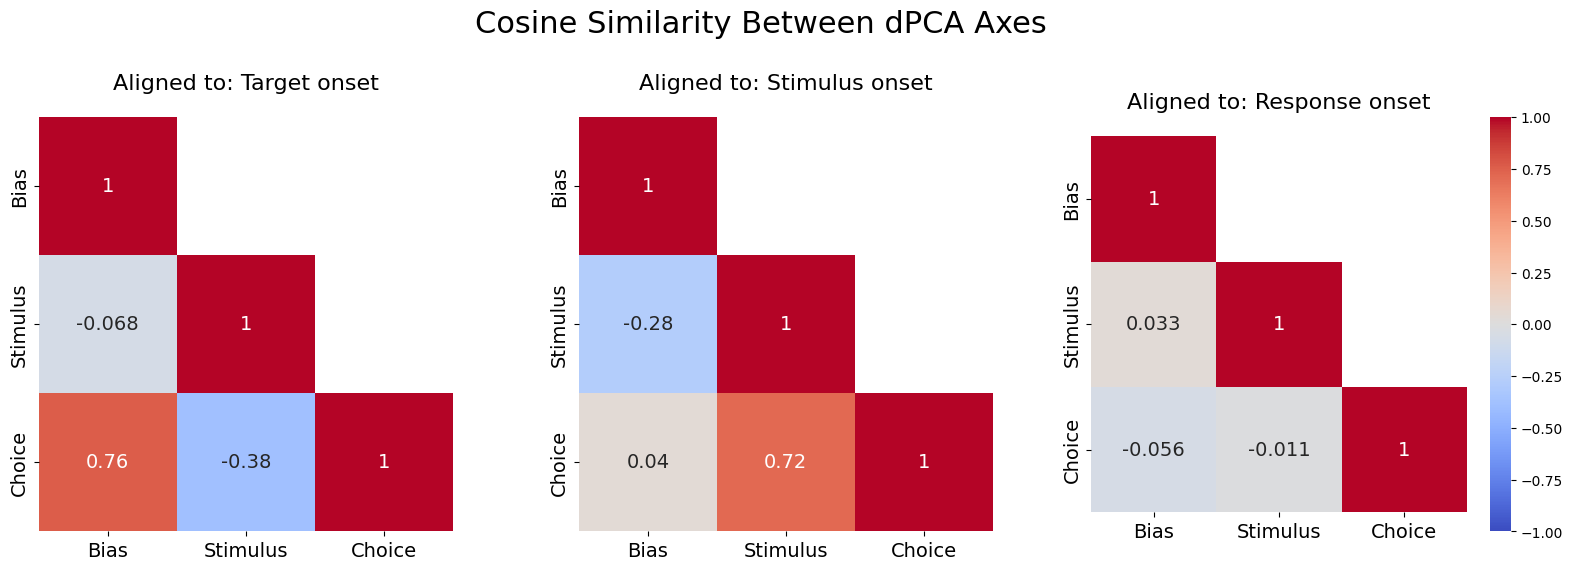

In [306]:
from matplotlib.colors import LinearSegmentedColormap

dpca_axes = ['b', 's', 'c']
corr_dict = {"toRF": [], "awayRF": []}

loadings = awayRF_loadings
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
# First, compute all correlation matrices to find global vmin and vmax
all_corrs = []
for idx in range(len(align_labels)):
    corr_matrix = np.zeros((len(dpca_axes), len(dpca_axes)))
    for i, a1 in enumerate(dpca_axes):
        for j, a2 in enumerate(dpca_axes):
            corr_matrix[i, j] = 1 - cosine(loadings[a1][idx], loadings[a2][idx])
    all_corrs.append(corr_matrix)

# # Find global min and max for color scale

for idx, align_label in enumerate(align_labels):
    corr_matrix = all_corrs[idx]

    # Mask upper triangle (excluding diagonal)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    sns.heatmap(corr_matrix,
                xticklabels=[marginalization[k] for k in dpca_axes],
                yticklabels=[marginalization[k] for k in dpca_axes],
                annot=True,
                annot_kws={"size": 14},   # <-- increase annotation font size here
                cmap="coolwarm",
                mask=mask,
                square=True,
                vmin=-1,
                vmax=1,
                cbar=(idx == len(align_labels) - 1),  # show colorbar only on last plot
                ax=axs[idx])
    axs[idx].tick_params(axis='x', labelsize=14)
    axs[idx].tick_params(axis='y', labelsize=14)
    axs[idx].set_title(f"Aligned to: {align_label.replace('_', ' ').capitalize()}", fontsize=16, pad=20)

corr_dict["awayRF"] = np.array(all_corrs)
plt.suptitle("Cosine Similarity Between dPCA Axes", fontsize=22)
plt.subplots_adjust(top=0.80, wspace=0.15)
# plt.tight_layout()
plt.show()


loadings = toRF_loadings
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
# First, compute all correlation matrices to find global vmin and vmax
all_corrs = []
for idx in range(len(align_labels)):
    corr_matrix = np.zeros((len(dpca_axes), len(dpca_axes)))
    for i, a1 in enumerate(dpca_axes):
        for j, a2 in enumerate(dpca_axes):
            corr_matrix[i, j] = 1 - cosine(loadings[a1][idx], loadings[a2][idx])
    all_corrs.append(corr_matrix)

# # Find global min and max for color scale

for idx, align_label in enumerate(align_labels):
    corr_matrix = all_corrs[idx]

    # Mask upper triangle (excluding diagonal)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    sns.heatmap(corr_matrix,
                xticklabels=[marginalization[k] for k in dpca_axes],
                yticklabels=[marginalization[k] for k in dpca_axes],
                annot=True,
                annot_kws={"size": 14},   # <-- increase annotation font size here
                cmap="coolwarm",
                mask=mask,
                square=True,
                vmin=-1,
                vmax=1,
                cbar=(idx == len(align_labels) - 1),  # show colorbar only on last plot
                ax=axs[idx])
    axs[idx].tick_params(axis='x', labelsize=14)
    axs[idx].tick_params(axis='y', labelsize=14)
    axs[idx].set_title(f"Aligned to: {align_label.replace('_', ' ').capitalize()}", fontsize=16, pad=20)

corr_dict["toRF"] = np.array(all_corrs)
plt.suptitle("Cosine Similarity Between dPCA Axes", fontsize=22)
plt.subplots_adjust(top=0.80, wspace=0.15)
# plt.tight_layout()
plt.show()


In [307]:
corr_dict['toRF']

array([[[ 1.        , -0.06808007,  0.76294152],
        [-0.06808007,  1.        , -0.38468267],
        [ 0.76294152, -0.38468267,  1.        ]],

       [[ 1.        , -0.27837663,  0.0399408 ],
        [-0.27837663,  1.        ,  0.71601618],
        [ 0.0399408 ,  0.71601618,  1.        ]],

       [[ 1.        ,  0.03343587, -0.05565508],
        [ 0.03343587,  1.        , -0.01054992],
        [-0.05565508, -0.01054992,  1.        ]]])

In [305]:
np.array(corr_dict['toRF']).shape

(3, 3, 3)

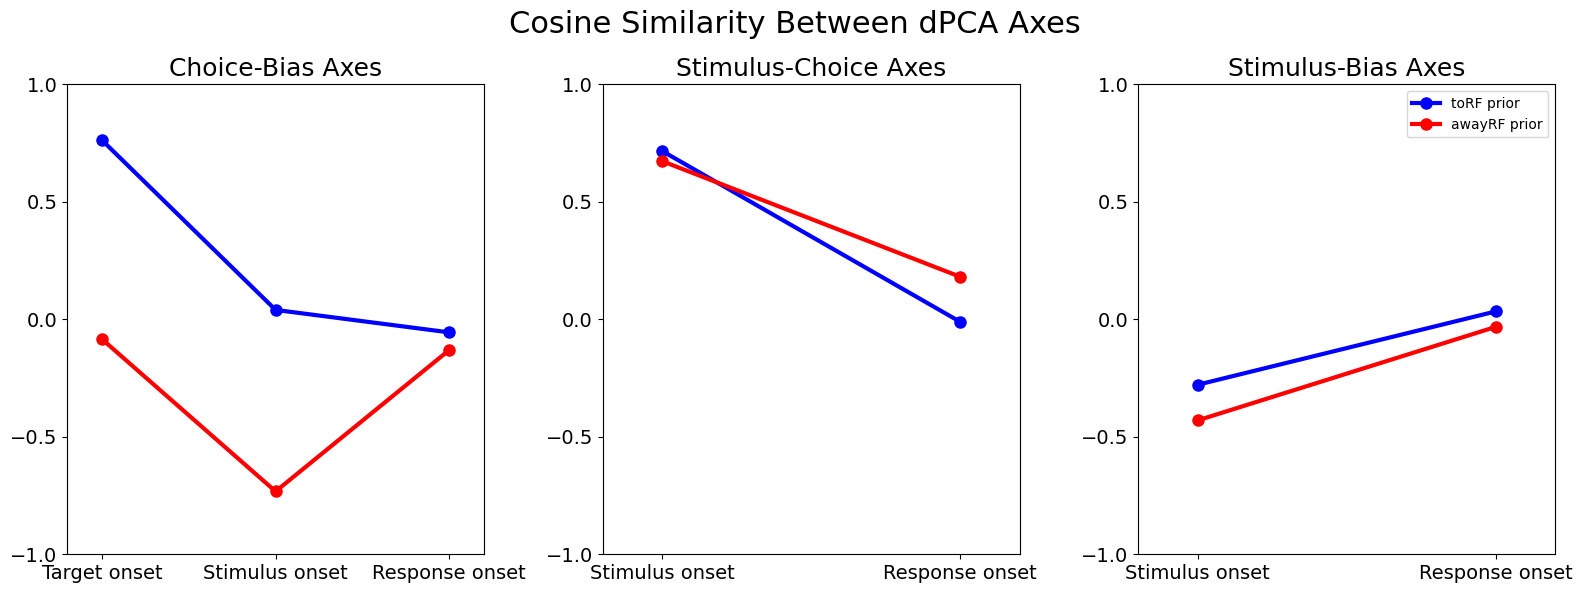

In [346]:
choice_bias_idx = [2,0]
stimulus_bias_idx = [1,0]
stimulus_choice_idx = [1,2]
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
plt.plot(corr_dict['toRF'][:,choice_bias_idx[0],choice_bias_idx[1]], label='toRF prior', color='blue', marker='o', linewidth=3, markersize=8)
plt.plot(corr_dict['awayRF'][:,choice_bias_idx[0],choice_bias_idx[1]], label='awayRF prior', color='red', marker='o', linewidth=3, markersize=8)
plt.xlim(-0.2, 2.2)
plt.ylim(-1, 1)
plt.title('Choice-Bias Axes', fontsize=18)
plt.xticks([0,1,2], [align_label.replace('_', ' ').capitalize() for align_label in align_labels], fontsize=14)
plt.yticks(np.arange(-1, 1.1, 0.5), fontsize=14)
plt.subplot(1, 3, 2)
plt.plot([1,2], corr_dict['toRF'][1:,stimulus_choice_idx[0],stimulus_choice_idx[1]], label='toRF prior', color='blue', marker='o', linewidth=3, markersize=8)
plt.plot([1,2], corr_dict['awayRF'][1:,stimulus_choice_idx[0],stimulus_choice_idx[1]], label='awayRF prior', color='red', marker='o', linewidth=3, markersize=8)
plt.ylim(-1, 1)
plt.title('Stimulus-Choice Axes', fontsize=18)
plt.xticks([0,1,2], [align_label.replace('_', ' ').capitalize() for align_label in align_labels], fontsize=14)
plt.yticks(np.arange(-1, 1.1, 0.5), fontsize=14)
plt.xlim(0.8, 2.2)
plt.subplot(1, 3, 3)
plt.plot([1,2], corr_dict['toRF'][1:,stimulus_bias_idx[0],stimulus_bias_idx[1]], label='toRF prior', color='blue', marker='o', linewidth=3, markersize=8)
plt.plot([1,2], corr_dict['awayRF'][1:,stimulus_bias_idx[0],stimulus_bias_idx[1]], label='awayRF prior', color='red', marker='o', linewidth=3, markersize=8)
plt.ylim(-1, 1)
plt.title('Stimulus-Bias Axes', fontsize=18)
plt.xticks([0,1,2], [align_label.replace('_', ' ').capitalize() for align_label in align_labels], fontsize=14)
plt.yticks(np.arange(-1, 1.1, 0.5), fontsize=14)
plt.xlim(0.8, 2.2)

plt.suptitle('Cosine Similarity Between dPCA Axes', fontsize=22)



plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
choice_bias_idx = [2,0]
plt.figure(figsize=(8, 6))
plt.plot(corr_dict['toRF'][:,choice_bias_idx[0],choice_bias_idx[1]], label='toRF prior', color='blue', marker='o', linewidth=3, markersize=8)
plt.plot(corr_dict['awayRF'][:,choice_bias_idx[0],choice_bias_idx[1]], label='awayRF prior', color='red', marker='o', linewidth=3, markersize=8)
plt.xlim(-0.2, 2.2)
plt.ylim(-1, 1)
plt.title('Cosine Similarity Between Choice-Bias Axes Across Alignments', fontsize=18)
plt.xticks([0,1,2], [align_label.replace('_', ' ').capitalize() for align_label in align_labels], fontsize=14)
plt.yticks(np.arange(-1, 1.1, 0.5), fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

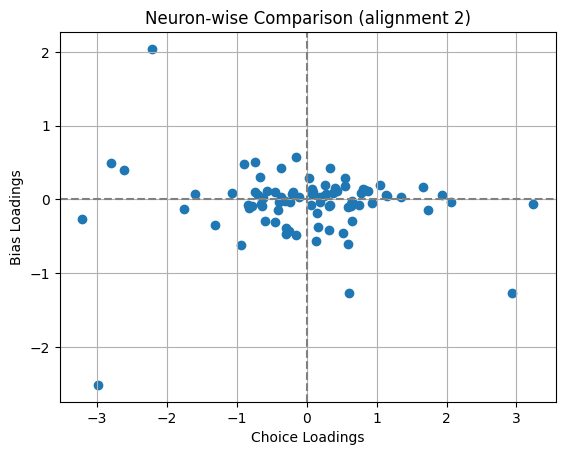

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(loadings['c'][i], loadings['b'][i])
plt.xlabel("Choice Loadings")
plt.ylabel("Bias Loadings")
plt.title(f"Neuron-wise Comparison (alignment {i})")
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.grid(True)
plt.show()


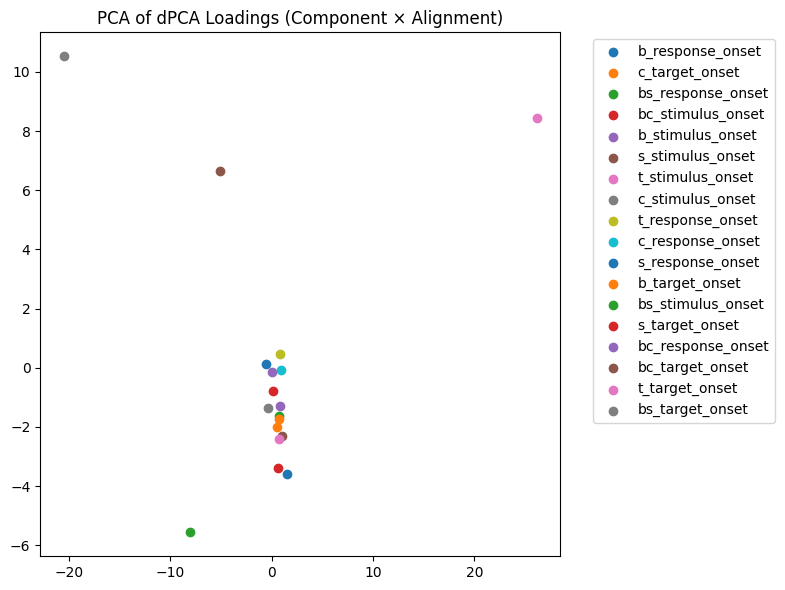

In [91]:
from sklearn.decomposition import PCA
import numpy as np

X = []
labels = []

for dpca_axis in loadings:
    for i, align in enumerate(align_labels):
        vec = loadings[dpca_axis][i]
        X.append(vec)
        labels.append(f"{dpca_axis}_{align}")

X = np.array(X)
proj = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(8,6))
for label in set(labels):
    idxs = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(proj[idxs, 0], proj[idxs, 1], label=label)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA of dPCA Loadings (Component × Alignment)")
plt.tight_layout()
plt.show()


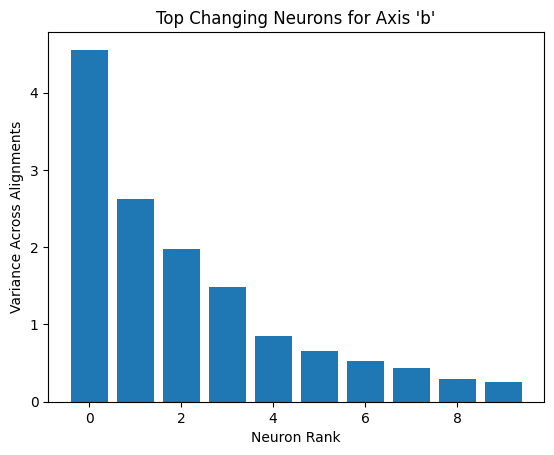

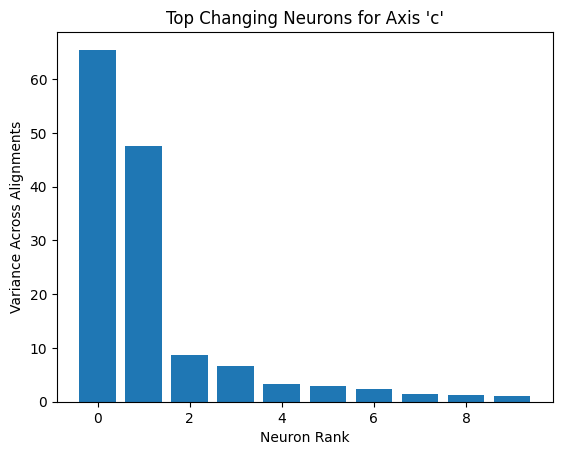

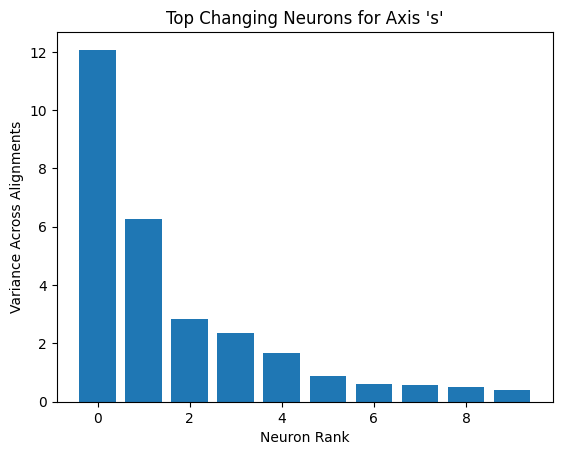

In [93]:
import numpy as np

for dpca_axis in ['b', 'c', 's']:
    var_across_align = np.var(loadings[dpca_axis], axis=0)
    top_changing = np.argsort(var_across_align)[::-1][:10]

    plt.bar(range(10), var_across_align[top_changing])
    plt.title(f"Top Changing Neurons for Axis '{dpca_axis}'")
    plt.xlabel("Neuron Rank")
    plt.ylabel("Variance Across Alignments")
    plt.show()


In [78]:
dpca_axis_mapping = {
    "bias": 'b',
    "stimulus": 's',
    "choice": 'c',
    "bias-stimulus": 'bs',
    "bias-choice": 'bc',
    "time": 't'
}

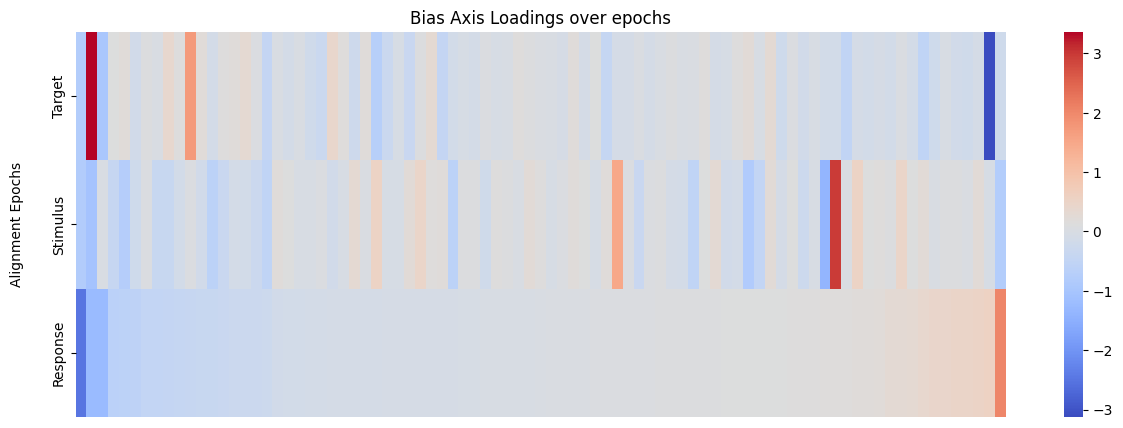

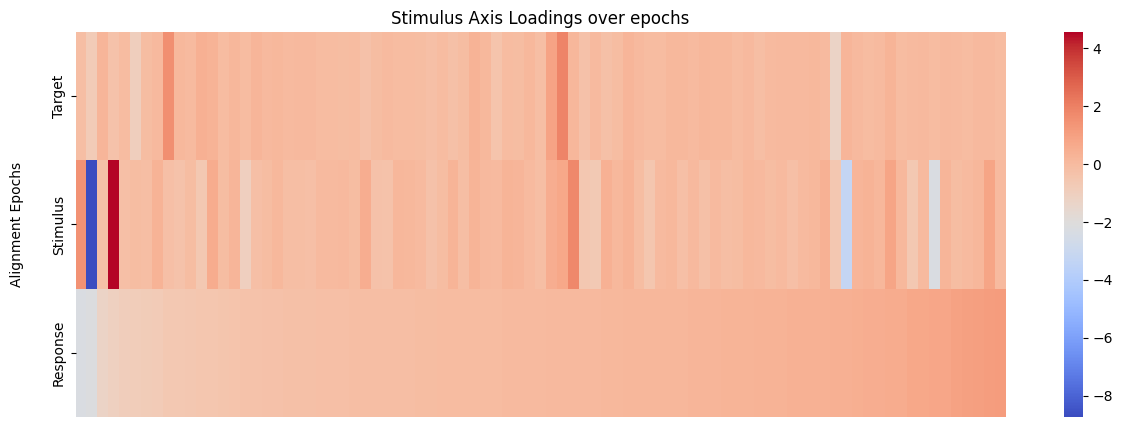

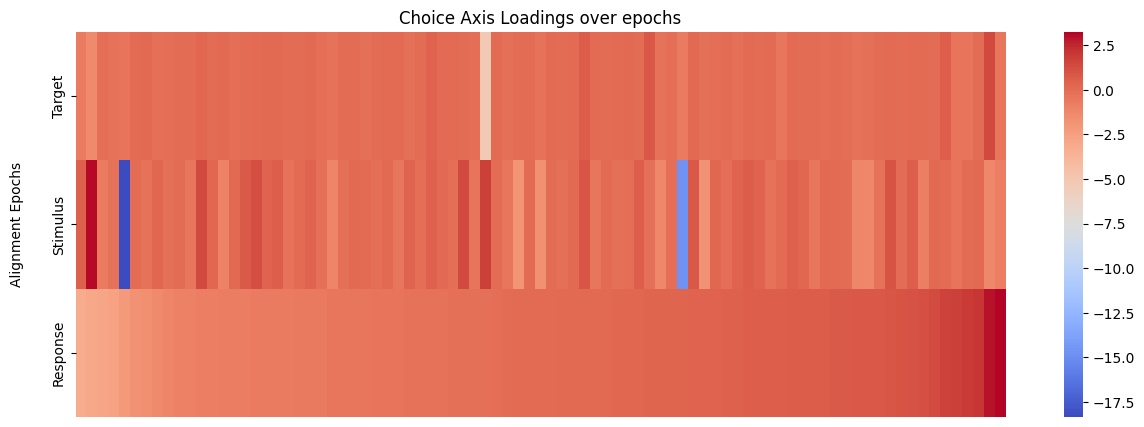

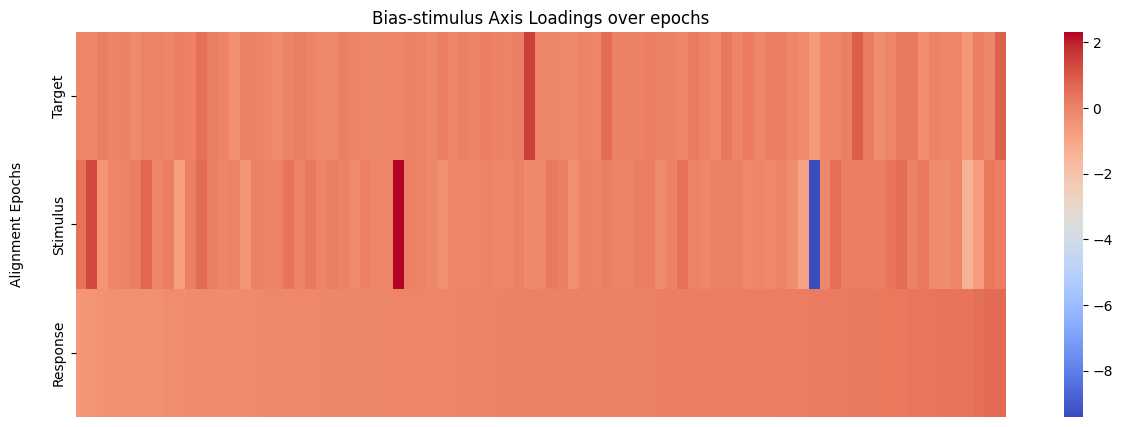

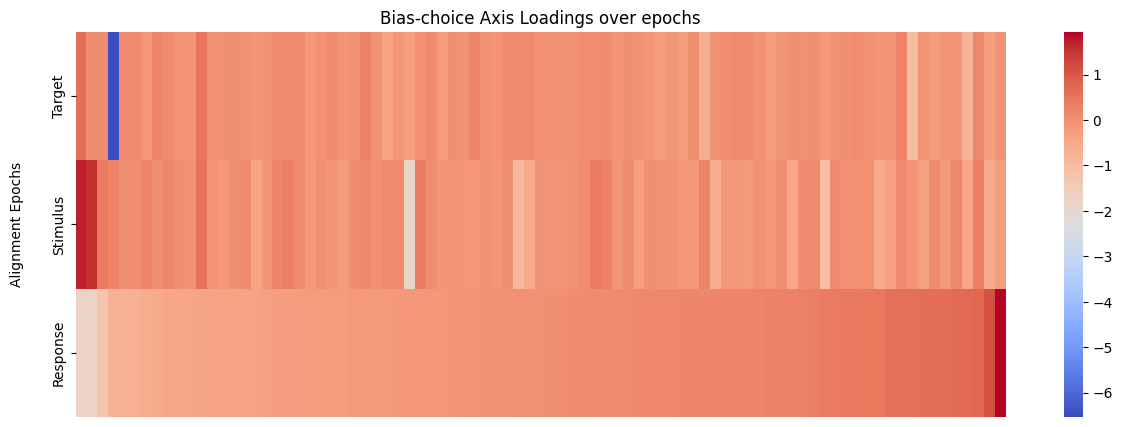

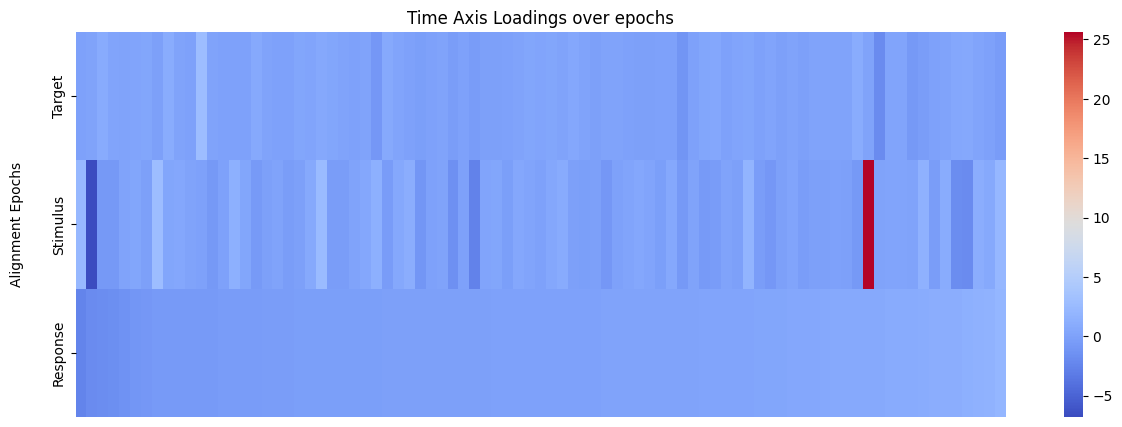

In [81]:
for label, dpca_axis in dpca_axis_mapping.items():
    sorted_idx = np.argsort(loadings[dpca_axis][2,:])
    plt.figure(figsize=(15, 5))
    sns.heatmap(loadings[dpca_axis][:,sorted_idx],cmap='coolwarm')
    plt.yticks([0.5,1.5,2.5],["Target","Stimulus","Response"]);
    plt.ylabel("Alignment Epochs", labelpad=20)
    plt.xticks([])
    plt.title(f'{label.capitalize()} Axis Loadings over epochs');